# Single-phase MC-PILCO — evaluation & comparison

One consolidated notebook, merging the previously separate scripts/notebooks:

- **`03_compare_rl_vs_pid`** — the trained RL policy vs the same-seed PID/recipe baseline on a
  block of held-out seeds (paired yield statistics + seed-averaged trajectories).
- **`analyze_single_phase`** — per-episode training progression, every observation overlaid, and
  the Fs recipe-vs-RL residual.
- **`diagnose_gp` / `diagnose_gp_updated`** — GP model quality: one-step R², per-dim error,
  local error across the batch, k-step-ahead error growth, and the short-horizon optimiser-window
  / recipe-anchor diagnostic.

Run top-to-bottom. Pick the run under test in the **Config** cell. The heavy cells (held-out
evaluation, GP reconstruction) each take a while because they re-simulate full fermentation batches.


## 0. Setup — imports, repo root & path


In [30]:
%matplotlib inline
import os, sys, json, pickle, contextlib, io, glob, re, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats

import os as _os, sys as _sys
_ROOT = _os.path.dirname(_os.path.abspath(""))
_sys.path.insert(0, _ROOT)
_sys.path.insert(0, _os.path.dirname(_ROOT))

import mcpilco.pensim_wrapper as _pensim_wrapper
import mcpilco.model_learning_det_time as _model_learning_det_time
import mcpilco.penicillin_cost as _penicillin_cost
import mcpilco.config_single_phase as _config_single_phase

_pensim_wrapper = importlib.reload(_pensim_wrapper)
_model_learning_det_time = importlib.reload(_model_learning_det_time)
_penicillin_cost = importlib.reload(_penicillin_cost)
_config_single_phase = importlib.reload(_config_single_phase)

from mcpilco.config_single_phase import get_config
from mcpilco.pensim_wrapper import (PenSimWrapper, PenSimMCPILCO, STATE_NAMES, STATE_DIM, ACTION_DIM,
                                    T_SAMPLING, CONTROL_H, VISC_MAX, WARMUP_H, PAA_BAND, FS_SCALE)
from experiments.eval_utils import yield_kg, constraint_diagnostics

print("state:", STATE_NAMES)
print("STATE_DIM:", STATE_DIM)

state: ['Wt', 'X', 'P', 'Viscosity', 'time']
STATE_DIM: 5


## 1. Config — which run to evaluate


In [31]:
SEED             = 3
RUN_SUFFIX       = 33
NUM_TRIALS       = 5
FAST             = False
GP_TRIAL         = None
OPTIM_HORIZON    = None
NUM_ANCHORS      = None
NUM_EXPLORATIONS = 5

N_EVAL_SEEDS = 5
EVAL_BASE    = 700000
COMPARE_SEED = EVAL_BASE

# Every training episode runs on this one fixed batch realisation
# (get_data_from_system passes seed=seed_offset), so it is the only recipe
# baseline that pairs with the episodes in section B.
TRAIN_SEED = get_config(seed=SEED)["wrapper_par"]["seed_offset"]

RESULTS_DIR = os.path.join(_ROOT, f"results/single_phase/seed{SEED}_{RUN_SUFFIX}")
RUN_DIR = Path(RESULTS_DIR)
assert (RUN_DIR / "log.pkl").exists(), f"no log.pkl under {RUN_DIR}"
print("run dir:", RUN_DIR)


run dir: /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase/seed3_33


## 2. Shared helpers


In [32]:
REF_STYLE   = dict(color="red", lw=2.2, ls="--", zorder=6)
MODEL_STYLE = dict(color="C0", lw=2.0, zorder=5)


def _denorm(x, lo, hi):
    return lo + (np.asarray(x) + 1.0) * (hi - lo) / 2.0


def _denorm_delta(d, lo, hi):
    return np.asarray(d) * (hi - lo) / 2.0


def _denorm_phys(x, name):
    """Denormalise state channel `name` to physical units, inverting the log encode for
    logged channels (STATE_LOG_CHANNELS). Exact inverse of extract_state's encode->normalise;
    matches penicillin_cost._cost. For non-logged channels decode_state_value is the identity."""
    return decode_state_value(name, _denorm(x, *STATE_RANGES[name]))


def final_P(state_norm):
    P = _denorm_phys(np.asarray(state_norm)[:, P_IDX], "P")
    return float(P[-1]), float(P.mean())


def decision_time_grid(N):
    """Physical decision-time axis (h) for a stored trajectory of N samples (N = n_decisions+1).

    Uses the TRUE decision spacing T_SAMPLING and the true first-sample time (K_WARM sim-steps in).
    The previous version spread N-1 intervals over CONTROL_H, giving 229.8/45 = 5.107 h instead of
    5.0 h -- a ~2% stretch that drifted ~5 h by batch end. That mis-aligned every recipe overlay and
    made the one-sim-step-wide discharge pulses (which drive the Wt sawtooth) invisible when the
    recipe was queried on this grid."""
    return K_WARM * STEP_IN_HOURS + np.arange(N) * T_SAMPLING


def _ep_color(i, n_ep, n_expl=NUM_EXPLORATIONS):
    """grey for exploration episodes, viridis (early->late) for the trials."""
    if i < n_expl:
        return "0.72"
    span = max(1, n_ep - n_expl - 1)
    return cm.viridis((i - n_expl) / span)


def _episode_colorbar(fig, ax, n_ep, n_expl=NUM_EXPLORATIONS, label="trial (early -> late)"):
    """Colorbar mapping the viridis shade used by _ep_color back to the TRIAL index.

    A legend can only show ONE swatch for "trials", but _ep_color encodes the trial ORDER as a
    viridis gradient (dark = first trial, yellow = last). Without this, that colour information --
    i.e. the training progression -- is drawn but unreadable. Mirrors _ep_color's normalisation
    exactly: trial i in [n_expl, n_ep-1] -> viridis((i - n_expl) / (n_ep - n_expl - 1)).
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    lo, hi = n_expl, max(n_expl + 1, n_ep - 1)
    sm = ScalarMappable(cmap=cm.viridis, norm=Normalize(vmin=lo, vmax=hi))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
    cb.set_label(label, fontsize=8)
    cb.ax.tick_params(labelsize=7)
    return cb


def run_arm(wrapper, seed, policy=None, pid_baseline=False):
    """Run one batch on `seed` and return its monitor dict."""
    wrapper.rollout(None, policy, CONTROL_H, T_SAMPLING, 0, seed=seed, pid_baseline=pid_baseline)
    return wrapper.monitor[-1]


def _resolve_trial(log, trial):
    """Default to the last trial that has a saved GP model."""
    avail = sorted(int(k.split("_")[-1]) for k in log if k.startswith("parameters_gp_"))
    if not avail:
        raise RuntimeError("log.pkl has no parameters_gp_<i> (no trained GP to load)")
    if trial is None:
        return avail[-1]
    if trial not in avail:
        raise RuntimeError(f"trial {trial} not in saved GP trials {avail}")
    return trial


def reconstruct(seed, num_trials, fast, log, idx):
    """Build a PenSimMCPILCO and load the trial-`idx` GP model from `log` (no training)."""
    cfg = get_config(seed=seed, num_trials=num_trials, fast=fast)
    cfg["mc_pilco_init"]["log_path"] = None
    agent = PenSimMCPILCO(pensim_wrapper=PenSimWrapper(**cfg["wrapper_par"]),
                          **cfg["mc_pilco_init"])
    agent.state_samples_history = log["state_samples_history"]
    agent.input_samples_history = log["input_samples_history"]
    agent.noiseless_states_history = log.get("noiseless_states_history",
                                             log["state_samples_history"])
    ml = agent.model_learning
    ml.gp_inputs = log[f"gp_inputs_{idx}"]
    ml.gp_output_list = log[f"gp_output_list_{idx}"]
    ml.num_samples = ml.gp_inputs.shape[0]
    ml.dim_state = len(STATE_NAMES)
    ml.init_gp_models()
    params = log[f"parameters_gp_{idx}"]
    for k in range(ml.num_gp):
        ml.gp_list[k].load_state_dict(params[k])
        # Faithful to training: config runs flg_norm=False, so GPs were fit on raw deltas
        # (norm_list=1). The old max|delta| here mis-scaled predictive variance by norm^2
        # (get_next_state), distorting every calibration/coverage diagnostic. Mirror flg_norm.
        ml.norm_list[k] = (torch.max(torch.abs(ml.gp_output_list[k]))
                           if getattr(ml, "flg_norm", False) else torch.tensor(1.0, dtype=agent.dtype))
    with torch.no_grad():
        for k in range(ml.num_gp):
            ml.pretrain_gp(k)
    ml.set_eval_mode()
    return agent


def _kstep_errors(agent, batch_idx, horizons, target_origins=60):
    """Sliding-origin k-step prediction error for one batch (open-loop, recorded actions).

    Returns rmse[len(horizons), STATE_DIM] in NORMALISED state space (NaN where unreachable)."""
    ml = agent.model_learning
    true = torch.tensor(agent.state_samples_history[batch_idx], dtype=agent.dtype, device=agent.device)
    inp = torch.tensor(agent.input_samples_history[batch_idx], dtype=agent.dtype, device=agent.device)
    T = true.shape[0]
    kmax = max(horizons)
    stride = max(1, int(np.ceil((T - 1) / target_origins)))
    sq = {k: [] for k in horizons}
    for t0 in range(0, T - 1, stride):
        steps = min(kmax, T - 1 - t0)
        cur = true[t0:t0 + 1, :]
        for j in range(1, steps + 1):
            cur, _, _ = ml.get_next_state(current_state=cur,
                                          current_input=inp[t0 + j - 1:t0 + j, :],
                                          particle_pred=False)
            if j in sq:
                err = (cur - true[t0 + j:t0 + j + 1, :]).ravel()
                sq[j].append((err ** 2).detach().cpu().numpy())
    rmse = np.full((len(horizons), STATE_DIM), np.nan)
    for r, k in enumerate(horizons):
        if sq[k]:
            rmse[r] = np.sqrt(np.mean(np.stack(sq[k], 0), axis=0))
    return rmse


def log_state_dims(log):
    """(policy_state_dim, gp_input_dim) recorded in a run log; None where not present."""
    pol = log.get("parameters_trial_list") or []
    p_dim = int(np.asarray(pol[-1]["centers"]).shape[1]) if pol else None
    gp_keys = [k for k in log if k.startswith("gp_inputs_")]
    g_dim = None
    if gp_keys:
        newest = max(gp_keys, key=lambda k: int(k.split("_")[-1]))
        g_dim = int(np.asarray(log[newest]).shape[1])
    return p_dim, g_dim


def find_compatible_runs(want_state_dim, limit=10):
    """Sibling runs whose saved policy matches the CURRENT state dimension."""
    out = []
    for d in sorted(Path(RESULTS_DIR).parent.glob("*/")):
        f = d / "log.pkl"
        if not f.exists():
            continue
        try:
            pol = pickle.load(open(f, "rb")).get("parameters_trial_list") or []
        except Exception:
            continue
        if pol and int(np.asarray(pol[-1]["centers"]).shape[1]) == want_state_dim:
            out.append(d.name)
    return out[:limit]


def assert_log_matches_code(log):
    """Fail EARLY and legibly when a run predates the current STATE_NAMES.

    Saved policies and GPs are tied to the state dimension they were trained with, so adding or
    removing a channel (e.g. Viscosity) invalidates older logs. Without this check the mismatch
    surfaces as a raw torch size-mismatch deep inside load_state_dict, which names neither the run
    nor the channel that changed."""
    p_dim, g_dim = log_state_dims(log)
    want_p, want_g = STATE_DIM, STATE_DIM + ACTION_DIM
    if (p_dim not in (None, want_p)) or (g_dim not in (None, want_g)):
        alts = find_compatible_runs(want_p)
        raise RuntimeError(
            f"run '{RUN_DIR.name}' was trained with a DIFFERENT state definition.\n"
            f"  saved:   policy state_dim={p_dim}, gp_input_dim={g_dim}\n"
            f"  current: policy state_dim={want_p}, gp_input_dim={want_g}\n"
            f"  current STATE_NAMES = {STATE_NAMES}\n"
            f"  -> point SEED/RUN_SUFFIX at a run trained with these channels, or retrain.\n"
            f"  compatible runs: {alts or 'NONE FOUND - retrain needed'}"
        )
    print(f"log/code state check OK: state_dim={want_p}, channels={STATE_NAMES}")


## 3. Load run artifacts (log, monitors, recipe reference, trained policy)


In [33]:
log = pickle.load(open(RUN_DIR / "log.pkl", "rb"))
mon_p = RUN_DIR / "monitor.pkl"
monitors = pickle.load(open(mon_p, "rb")) if mon_p.exists() else None
state_hist = log["state_samples_history"]
n_ep = len(state_hist)
n_trials_in_log = len(log.get("parameters_trial_list", [])) or NUM_TRIALS
assert_log_matches_code(log)
print(f"episodes: {n_ep} | trials in log: {n_trials_in_log}")


log/code state check OK: state_dim=5, channels=['Wt', 'X', 'P', 'Viscosity', 'time']
episodes: 10 | trials in log: 5


In [34]:
def _assert_policy_state_dim_ok(np_policy, label):
    """Fail fast, with a clear message, if this policy's saved weights don't match the CURRENT
    STATE_DIM/STATE_NAMES -- e.g. a checkpoint trained before a state channel (like DO2) was
    added. `load_state_dict` itself raises a clean shape-mismatch RuntimeError in a FRESH kernel,
    but that error can be masked in a kernel that hasn't been restarted since pensim_wrapper.py
    changed: some already-imported modules stay on the old STATE_DIM while others pick up the new
    one, so the mismatch can slip past loading and only show up as a garbage action fed into the
    simulator -- which can drive the ODE solver into a numerically pathological state that hangs
    for minutes instead of raising anything. This check calls the policy once, immediately, on a
    zero-vector of the CURRENT STATE_DIM, so a mismatch is caught here instead of inside a rollout.
    """
    test_state = np.zeros(STATE_DIM)
    try:
        action = np.asarray(np_policy(test_state, 0), dtype=float).ravel()
    except Exception as e:
        raise RuntimeError(
            f"{label}: policy forward pass failed on a {STATE_DIM}-dim state "
            f"(STATE_NAMES={STATE_NAMES}). This checkpoint was very likely trained under a "
            f"different state space and cannot be evaluated against the current environment "
            f"without retraining. If you just edited pensim_wrapper.py, RESTART THE KERNEL first "
            f"-- a stale module cache can mask this as something else entirely (e.g. a hang deep "
            f"in the ODE solver instead of this error)."
        ) from e
    if action.shape != (ACTION_DIM,) or not np.all(np.isfinite(action)):
        raise RuntimeError(
            f"{label}: policy output {action} is the wrong shape or non-finite for a "
            f"{STATE_DIM}-dim state -- treat this exactly like a dimension mismatch (see above)."
        )


_folder = str(RUN_DIR).rstrip("/") + "/"
_cfg_policy = get_config(seed=SEED, num_trials=n_trials_in_log)
eval_wrapper = PenSimWrapper()
policy_agent = PenSimMCPILCO(pensim_wrapper=eval_wrapper, **_cfg_policy["mc_pilco_init"])
policy_agent.load_policy_from_log(num_trial=n_trials_in_log, folder=_folder)
np_policy = policy_agent.control_policy.get_np_policy()
_assert_policy_state_dim_ok(np_policy, f"trial {n_trials_in_log} policy")
print(f"loaded trial {n_trials_in_log} policy from {_folder}")

# Recipe arm (pid_baseline=True == recipe: Fs = recipe Fs, all other streams recipe)
# on the same seed the run trained on: identical stochastic
# realisation, only the Fs action differs, so seed variance cancels.
base_mon = run_arm(eval_wrapper, TRAIN_SEED, policy=None, pid_baseline=True)
ref = {k: (np.asarray(base_mon["t"]), np.asarray(base_mon[k]))
       for k in ("P", "PAA", "Viscosity", "Fpaa", "Wt", "Fs")}
ref["yield"] = yield_kg(base_mon)
ref["final_P"] = float(base_mon["P"][-1])
ref_lbl = f"recipe (seed {TRAIN_SEED})"
print(f"recipe baseline on seed {TRAIN_SEED}: "
      f"final_P={ref['final_P']:.2f} g/L, yield={ref['yield']:.1f} kg")




Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}
[recipe-mean] P: 45 decisions from 4 recipe batches, normalised-log delta range [0.0000, 0.6057]


Get the exploration policy...


Get the control policy...


Get the cost function...

Loading policy from: /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase/seed3_33/log.pkl
loaded trial 5 policy from /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase/seed3_33/
recipe baseline on seed 3000: final_P=25.61 g/L, yield=3246.7 kg


# A. RL policy vs same-seed PID baseline

The recipe/PID baseline is run on the **same seed** as the RL policy, so each pair shares an
identical stochastic batch realisation and only the Fs (sugar-feed) action differs — the fair,
paired comparison. Evaluated on a block of held-out seeds disjoint from the training window.


## A.1 Evaluate on held-out seeds (paired)


In [35]:
# Training now runs EVERY episode on the single fixed realisation TRAIN_SEED
# (get_data_from_system passes seed=seed_offset), so the old "training window"
# [seed*1000, seed*1000+4+NUM_TRIALS] no longer describes anything real.
eval_seeds = [EVAL_BASE + i for i in range(N_EVAL_SEEDS)]
assert TRAIN_SEED not in eval_seeds, f"eval seeds must exclude TRAIN_SEED={TRAIN_SEED}"
print(f"train seed {TRAIN_SEED} | eval seeds {eval_seeds[0]}..{eval_seeds[-1]} (held out)")

rows, mons_rl, mons_recipe = [], [], []
for h in eval_seeds:
    m_rl = run_arm(eval_wrapper, h, policy=np_policy, pid_baseline=False)
    m_recipe = run_arm(eval_wrapper, h, policy=None, pid_baseline=True)
    mons_rl.append(m_rl)
    mons_recipe.append(m_recipe)
    y_rl, y_recipe = yield_kg(m_rl), yield_kg(m_recipe)
    row = {"seed": h, "yield_rl": y_rl, "yield_recipe": y_recipe, "delta": y_rl - y_recipe}
    row.update({f"rl_{k}": v for k, v in constraint_diagnostics(m_rl).items()})
    row.update({f"recipe_{k}": v for k, v in constraint_diagnostics(m_recipe).items()})
    rows.append(row)
    print(f"seed {h}: yield_rl={y_rl:8.2f}  yield_recipe={y_recipe:8.2f}  delta={y_rl - y_recipe:+8.2f}")

df = pd.DataFrame(rows)
df


train seed 3000 | eval seeds 700000..700004 (held out)
seed 700000: yield_rl= 2820.69  yield_recipe= 3467.33  delta= -646.64
seed 700001: yield_rl= 2757.29  yield_recipe= 3573.90  delta= -816.61
seed 700002: yield_rl= 3468.65  yield_recipe= 3696.62  delta= -227.97
seed 700003: yield_rl= 2840.44  yield_recipe= 3526.59  delta= -686.15
seed 700004: yield_rl= 2547.85  yield_recipe= 3214.51  delta= -666.65


,seed,yield_rl,yield_recipe,delta,rl_final_P,rl_max_Wt,rl_wt_overflow,rl_paa_frac_out_of_band,rl_max_viscosity,rl_visc_exceed,recipe_final_P,recipe_max_Wt,recipe_wt_overflow,recipe_paa_frac_out_of_band,recipe_max_viscosity,recipe_visc_exceed
0,700000,2820.693652,3467.328902,-646.635250,23.455633,95585.493100,False,0.012174,70.596118,False,27.424360,101050.051771,False,0.011304,81.007048,False
1,700001,2757.288800,3573.899211,-816.610411,22.952763,98375.717542,False,0.020000,61.617123,False,27.762091,106086.753636,False,0.019130,71.801539,False
2,700002,3468.653048,3696.618223,-227.965175,28.648150,96869.126081,False,0.000000,81.145325,False,30.024651,98603.657446,False,0.000000,89.916614,False
3,700003,2840.438972,3526.588600,-686.149628,23.184717,98888.069350,False,0.021739,65.166243,False,27.108314,105621.700489,False,0.020870,75.306299,False
4,700004,2547.853261,3214.506607,-666.653346,20.847353,95716.996752,False,0.024348,68.738464,False,24.884472,101732.672304,False,0.024348,79.894066,False


## A.2 Paired statistics (mean delta, 95% CI, t-test, Wilcoxon, win-rate)


In [36]:
delta = df["delta"].values
n = len(delta)
mean_d = float(delta.mean())
se = float(delta.std(ddof=1) / np.sqrt(n)) if n > 1 else float("nan")
ci = 1.96 * se
t_p = float(stats.ttest_rel(df["yield_rl"], df["yield_recipe"]).pvalue) if n > 1 else float("nan")
try:
    w_p = float(stats.wilcoxon(df["yield_rl"], df["yield_recipe"]).pvalue)
except ValueError:
    w_p = float("nan")

summary = pd.DataFrame([{
    "n_seeds": n,
    "mean_yield_rl": float(df["yield_rl"].mean()),
    "mean_yield_recipe": float(df["yield_recipe"].mean()),
    "mean_delta": mean_d,
    "delta_ci95_lo": mean_d - ci,
    "delta_ci95_hi": mean_d + ci,
    "ttest_p": t_p,
    "wilcoxon_p": w_p,
    "winrate_rl_gt_recipe": float((delta > 0).mean()),
}])
print("=== SUMMARY (RL vs recipe, held-out) ===")
print(summary.T.to_string(header=False))
summary


=== SUMMARY (RL vs recipe, held-out) ===
n_seeds                  5.000000
mean_yield_rl         2886.985547
mean_yield_recipe     3495.788309
mean_delta            -608.802762
delta_ci95_lo         -804.303213
delta_ci95_hi         -413.302311
ttest_p                  0.003646
wilcoxon_p               0.062500
winrate_rl_gt_recipe     0.000000


,n_seeds,mean_yield_rl,mean_yield_recipe,mean_delta,delta_ci95_lo,delta_ci95_hi,ttest_p,wilcoxon_p,winrate_rl_gt_recipe
0,5,2886.985547,3495.788309,-608.802762,-804.303213,-413.302311,0.003646,0.0625,0.0


## A.3 Paired yield, per-seed delta, seed-averaged penicillin


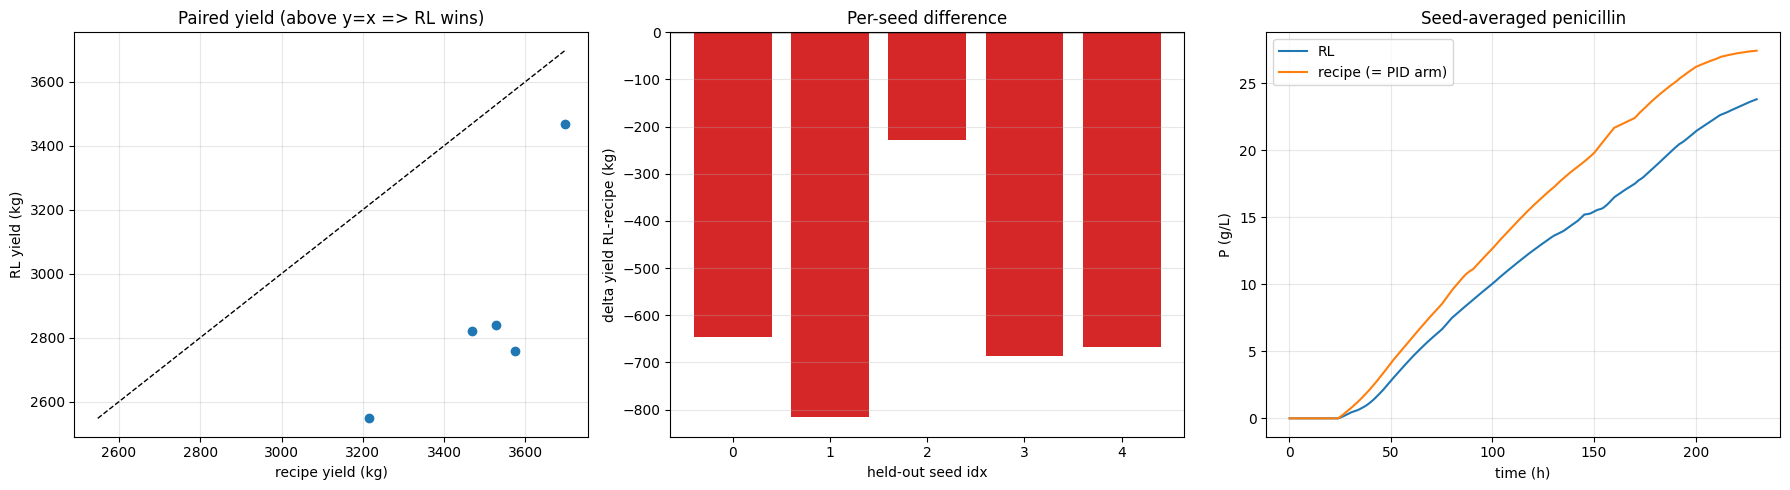

In [37]:
t = np.asarray(mons_rl[0]["t"])
avg = lambda mons, key: np.mean([m[key] for m in mons], axis=0)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
lo = float(min(df["yield_recipe"].min(), df["yield_rl"].min()))
hi = float(max(df["yield_recipe"].max(), df["yield_rl"].max()))
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].scatter(df["yield_recipe"], df["yield_rl"], c="C0")
ax[0].set_xlabel("recipe yield (kg)"); ax[0].set_ylabel("RL yield (kg)")
ax[0].set_title("Paired yield (above y=x => RL wins)"); ax[0].grid(alpha=.3)

ax[1].bar(np.arange(len(df)), df["delta"].values,
          color=["C2" if d > 0 else "C3" for d in df["delta"]])
ax[1].axhline(0, color="k", lw=1)
ax[1].set_xlabel("held-out seed idx"); ax[1].set_ylabel("delta yield RL-recipe (kg)")
ax[1].set_title("Per-seed difference"); ax[1].grid(alpha=.3, axis="y")

ax[2].plot(t, avg(mons_rl, "P"), label="RL", color="C0")
ax[2].plot(t, avg(mons_recipe, "P"), label="recipe (= PID arm)", color="C1")
ax[2].set_xlabel("time (h)"); ax[2].set_ylabel("P (g/L)")
ax[2].set_title("Seed-averaged penicillin"); ax[2].grid(alpha=.3); ax[2].legend()
fig.tight_layout(); plt.show()


## A.4 Total yield: RL vs baseline


/var/folders/95/gkrvd95s5g7dz0cz31qhbzk40000gn/T/ipykernel_52819/4190271328.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].grid(alpha=.3, axis="y"); ax[0].legend(fontsize=8)


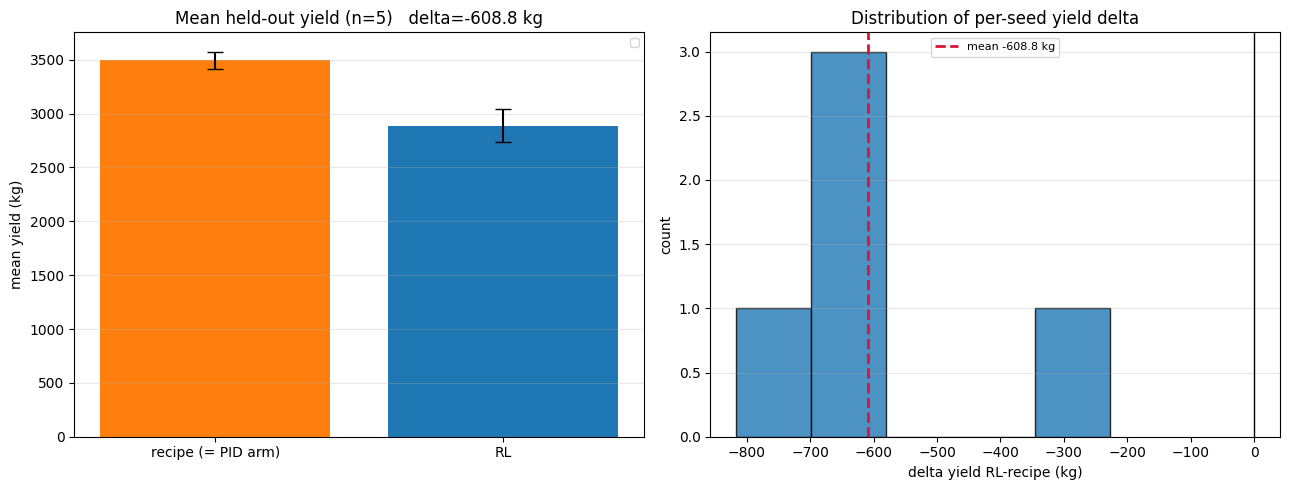

In [38]:
# NOTE: `pid_baseline=True` sets Fs = recipe Fs and every other stream is the recipe in
# BOTH arms, so the "PID" arm IS the recipe. The old red `ref["yield"]` line here was the
# SAME controller on a DIFFERENT seed (TRAIN_SEED): measured 3246.7 vs 3563.5 kg, a 317 kg
# gap that is pure seed noise (1.07 sd) and larger than the RL effect. Removed.
mean_rl, mean_recipe = float(df["yield_rl"].mean()), float(df["yield_recipe"].mean())
sem_rl = float(df["yield_rl"].std(ddof=1) / np.sqrt(n))
sem_recipe = float(df["yield_recipe"].std(ddof=1) / np.sqrt(n))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar([0, 1], [mean_recipe, mean_rl], yerr=[sem_recipe, sem_rl], capsize=6,
          color=["C1", "C0"])
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["recipe (= PID arm)", "RL"])
ax[0].set_ylabel("mean yield (kg)")
ax[0].set_title(f"Mean held-out yield (n={n})   delta={mean_rl - mean_recipe:+.1f} kg")
ax[0].grid(alpha=.3, axis="y"); ax[0].legend(fontsize=8)

ax[1].hist(df["delta"].values, bins=max(5, n // 2), color="C0", alpha=.8, edgecolor="k")
ax[1].axvline(0, color="k", lw=1)
ax[1].axvline(mean_d, color="crimson", ls="--", lw=2, label=f"mean {mean_d:+.1f} kg")
ax[1].set_xlabel("delta yield RL-recipe (kg)"); ax[1].set_ylabel("count")
ax[1].set_title("Distribution of per-seed yield delta"); ax[1].grid(alpha=.3, axis="y"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


## A.5 Seed-averaged control & constraint variables (RL vs PID)


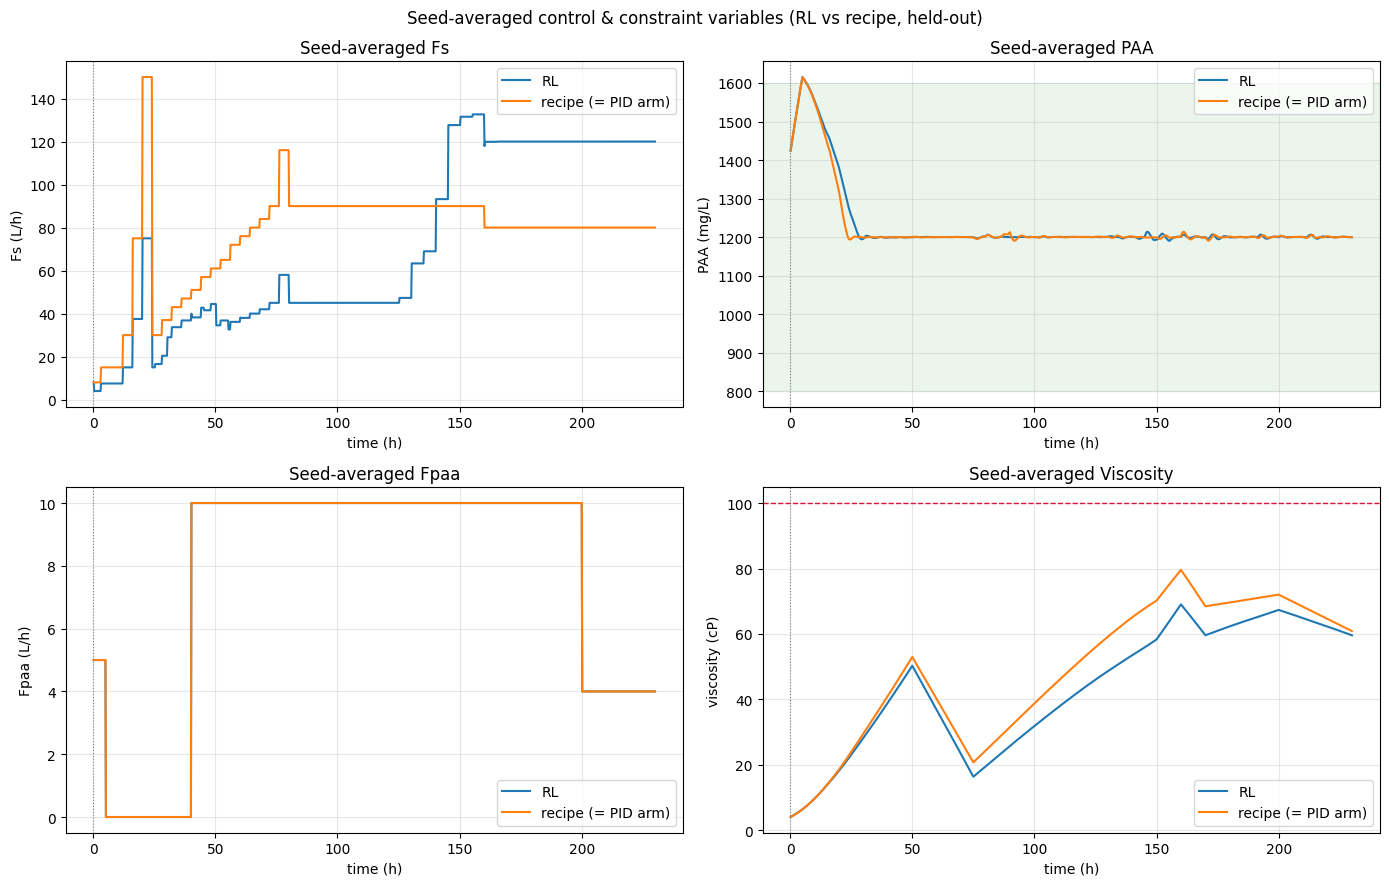

In [39]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
panels = [("Fs", ax[0, 0], "Fs (L/h)"), ("PAA", ax[0, 1], "PAA (mg/L)"),
          ("Fpaa", ax[1, 0], "Fpaa (L/h)"), ("Viscosity", ax[1, 1], "viscosity (cP)")]
for key, axx, yl in panels:
    axx.plot(t, avg(mons_rl, key), label="RL", color="C0")
    axx.plot(t, avg(mons_recipe, key), label="recipe (= PID arm)", color="C1")
    axx.axvline(WARMUP_H, color="gray", ls=":", lw=.8)
    axx.set_xlabel("time (h)"); axx.set_ylabel(yl); axx.set_title(f"Seed-averaged {key}")
    axx.grid(alpha=.3); axx.legend()
ax[0, 1].axhspan(*PAA_BAND, color="green", alpha=.08)
ax[1, 1].axhline(VISC_MAX, color="crimson", ls="--", lw=1)
fig.suptitle("Seed-averaged control & constraint variables (RL vs recipe, held-out)")
fig.tight_layout(); plt.show()


## A.6 Model vs recipe on a single shared seed

Re-run the simulator twice on one shared seed — trained policy vs recipe/PID — so the batch
realisation is identical and only the Fs action differs. All key variables side by side.


seed 700000: yield model= 2820.69 kg  recipe= 3467.33 kg  delta= -646.64 kg


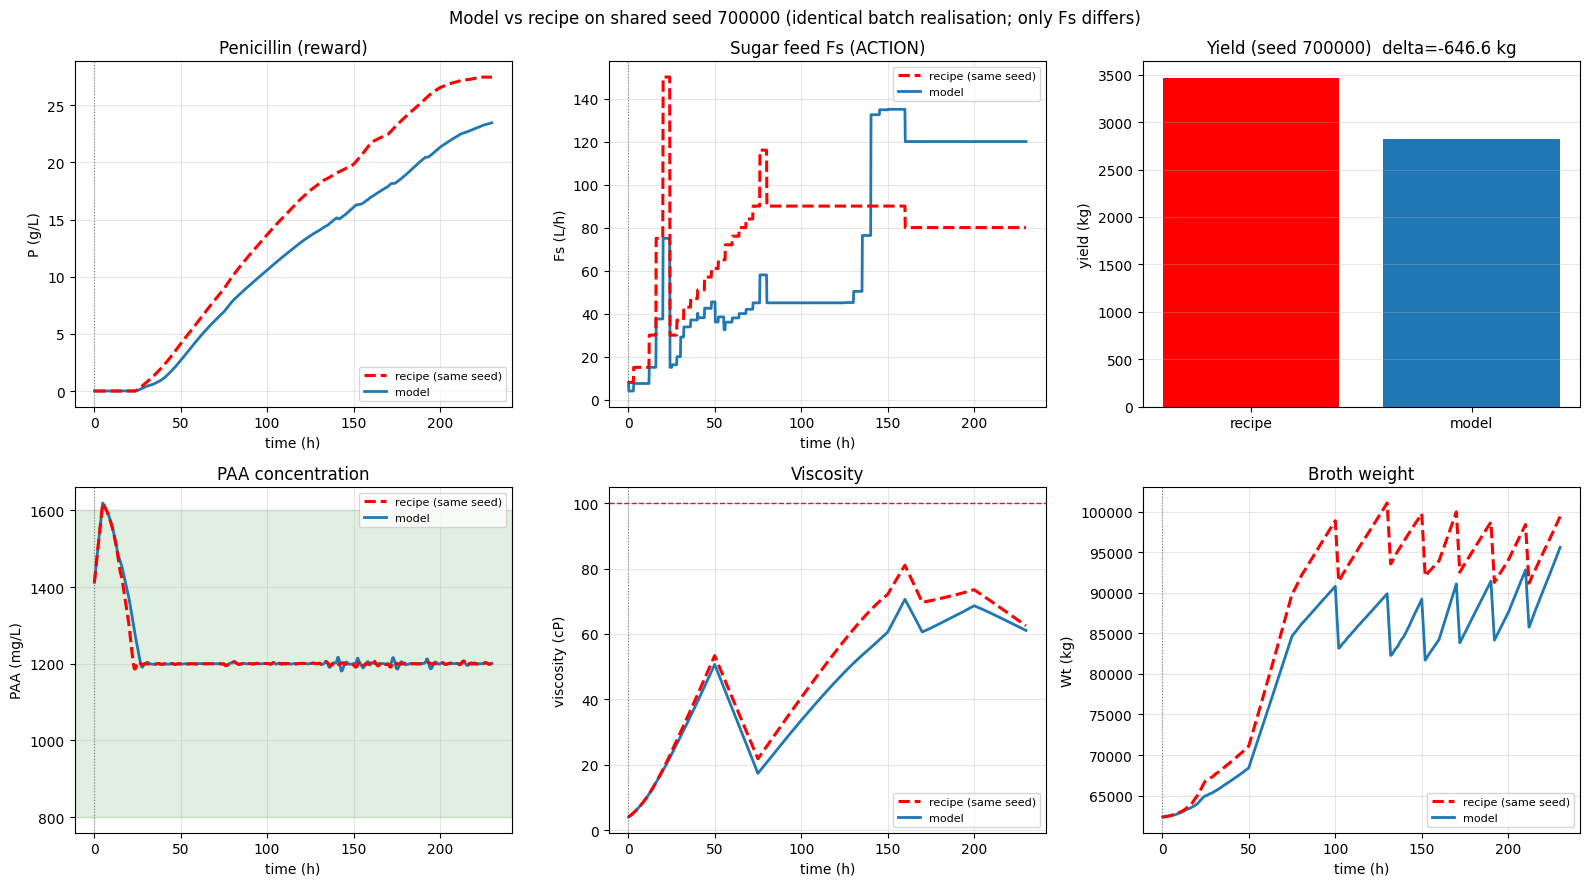

In [40]:
m_rl_s = run_arm(eval_wrapper, COMPARE_SEED, policy=np_policy, pid_baseline=False)
m_recipe_s = run_arm(eval_wrapper, COMPARE_SEED, policy=None, pid_baseline=True)
y_rl_s, y_recipe_s = yield_kg(m_rl_s), yield_kg(m_recipe_s)
print(f"seed {COMPARE_SEED}: yield model={y_rl_s:8.2f} kg  recipe={y_recipe_s:8.2f} kg  "
      f"delta={y_rl_s - y_recipe_s:+8.2f} kg")

fig, ax = plt.subplots(2, 3, figsize=(16, 9))
def _cmp(a, key, ylabel, title):
    a.plot(m_recipe_s["t"], m_recipe_s[key], **{**REF_STYLE, "label": "recipe (same seed)"})
    a.plot(m_rl_s["t"], m_rl_s[key], **{**MODEL_STYLE, "label": "model"})
    a.axvline(WARMUP_H, color="gray", ls=":", lw=.8)
    a.set_xlabel("time (h)"); a.set_ylabel(ylabel); a.set_title(title)
    a.grid(alpha=.3); a.legend(fontsize=8)

_cmp(ax[0, 0], "P", "P (g/L)", "Penicillin (reward)")
_cmp(ax[0, 1], "Fs", "Fs (L/h)", "Sugar feed Fs (ACTION)")
_cmp(ax[1, 0], "PAA", "PAA (mg/L)", "PAA concentration")
_cmp(ax[1, 1], "Viscosity", "viscosity (cP)", "Viscosity")
_cmp(ax[1, 2], "Wt", "Wt (kg)", "Broth weight")
ax[1, 0].axhspan(*PAA_BAND, color="green", alpha=.12)
ax[1, 1].axhline(VISC_MAX, color="crimson", ls="--", lw=1)

ax[0, 2].bar([0, 1], [y_recipe_s, y_rl_s], color=[REF_STYLE["color"], "C0"])
ax[0, 2].set_xticks([0, 1]); ax[0, 2].set_xticklabels(["recipe", "model"])
ax[0, 2].set_ylabel("yield (kg)")
ax[0, 2].set_title(f"Yield (seed {COMPARE_SEED})  delta={y_rl_s - y_recipe_s:+.1f} kg")
ax[0, 2].grid(alpha=.3, axis="y")
fig.suptitle(f"Model vs recipe on shared seed {COMPARE_SEED} "
             f"(identical batch realisation; only Fs differs)")
fig.tight_layout(); plt.show()


## A.7 Fs: recipe vs RL residual, and the recovered action

`mon["Fs"]` is the applied feed `recipe_Fs(t)*(1 + FS_SCALE*a_fs)`. On a shared seed the recipe
denominator is identical, so `Fs_rl / Fs_recipe` recovers the pure policy output: a staircase with
one flat step per decision (`a=0` == recipe).


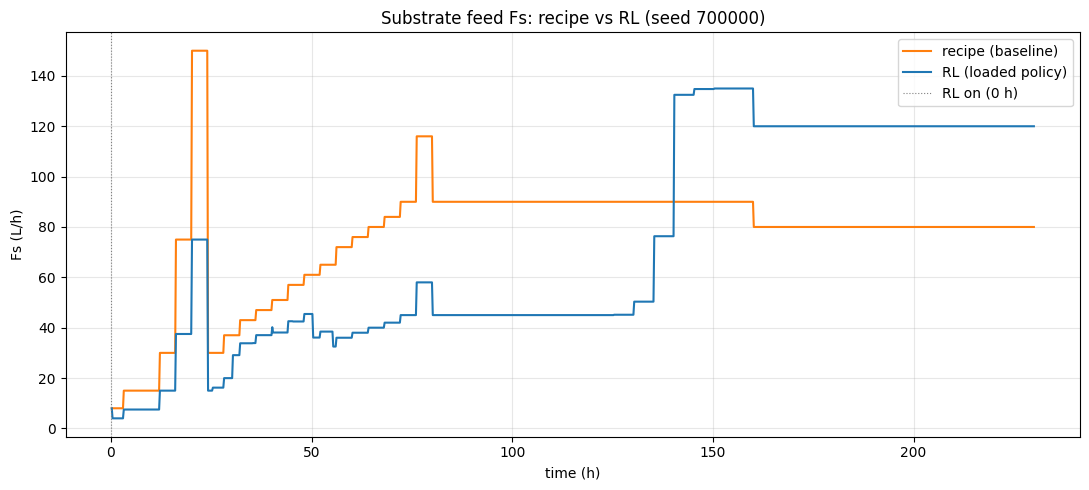

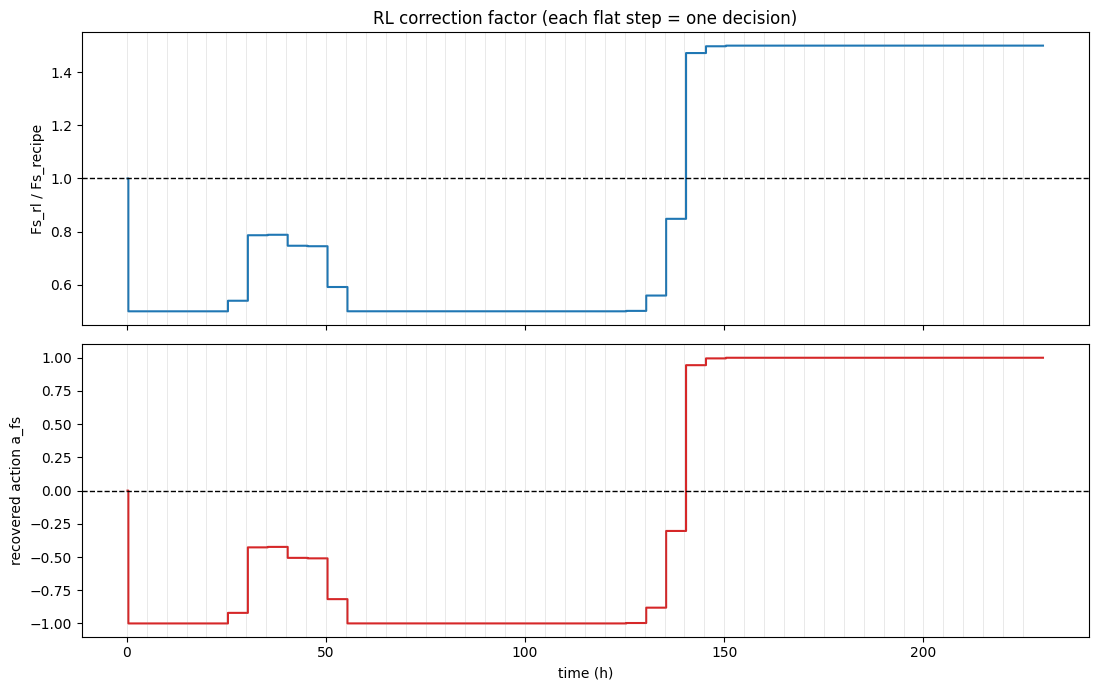

distinct action levels held over the batch: 23 (expected ~45 at T_SAMPLING=5 h)


In [41]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(m_recipe_s["t"], m_recipe_s["Fs"], label="recipe (baseline)", color="C1")
ax.plot(m_rl_s["t"], m_rl_s["Fs"], label="RL (loaded policy)", color="C0")
ax.axvline(WARMUP_H, color="gray", ls=":", lw=.8, label=f"RL on ({WARMUP_H:g} h)")
ax.set_xlabel("time (h)"); ax.set_ylabel("Fs (L/h)")
ax.set_title(f"Substrate feed Fs: recipe vs RL (seed {COMPARE_SEED})")
ax.grid(alpha=.3); ax.legend(); fig.tight_layout(); plt.show()

t_fs = np.asarray(m_rl_s["t"])
ratio = np.asarray(m_rl_s["Fs"]) / np.maximum(np.asarray(m_recipe_s["Fs"]), 1e-9)
a_fs = (ratio - 1.0) / FS_SCALE

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(t_fs, ratio, color="C0", drawstyle="steps-post")
ax[0].axhline(1.0, color="k", lw=1, ls="--")
ax[0].set_ylabel("Fs_rl / Fs_recipe")
ax[0].set_title("RL correction factor (each flat step = one decision)")
ax[1].plot(t_fs, a_fs, color="C3", drawstyle="steps-post")
ax[1].axhline(0.0, color="k", lw=1, ls="--")
ax[1].set_ylabel("recovered action a_fs"); ax[1].set_xlabel("time (h)")
for tb in np.arange(WARMUP_H, t_fs[-1], T_SAMPLING):
    for a in ax:
        a.axvline(tb, color="grey", alpha=.2, lw=.6)
fig.tight_layout(); plt.show()
n_steps = int(np.sum(np.abs(np.diff(a_fs)) > 1e-6)) + 1
print(f"distinct action levels held over the batch: {n_steps} "
      f"(expected ~{int(CONTROL_H / T_SAMPLING)} at T_SAMPLING={T_SAMPLING:g} h)")


## A.8 Validation learning curve (fixed seeds) — does the policy actually improve?

B.1's per-episode bars still **cannot** answer this: the first `NUM_EXPLORATIONS` bars are
exploration, not the policy, and each episode's yield also reflects whatever the *exploration
policy* happened to do. (Training now runs every episode on the single fixed realisation
`TRAIN_SEED`, so seed-to-seed noise is no longer the confounder it once was — but the
exploration/policy mix still is.)

Here the **seeds are held fixed** and only the **policy stage** varies (loaded from
`log["parameters_trial_list"]`), and each stage is **paired against the recipe on the same seed** —
so seed variance cancels and any trend is genuinely the policy.




Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...
recipe baseline on [700000, 700001, 700002]: 3579.3 kg
  trial  1: yield=  3722.0 +/- 728.5 kg | paired delta vs recipe =   +142.7 kg
  trial  2: yield=  3009.9 +/- 1490.3 kg | paired delta vs recipe =   -569.3 kg
  trial  3: yield=  3795.0 +/- 446.1 kg | paired delta vs recipe =   +215.8 kg
  trial  4: yield=  2648.6 +/- 1443.7 kg | paired delta vs recipe =   -930.7 kg
  trial  5: yield=  3015.5 +/- 321.4 kg | paired delta vs recipe =   -563.7 kg


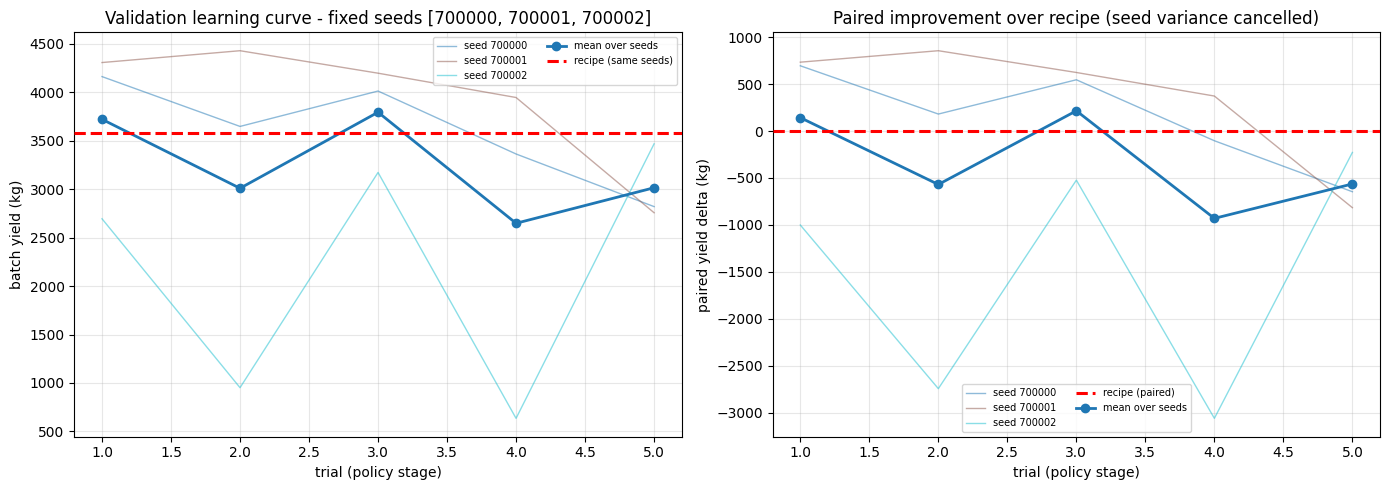


final policy: 3015.5 kg vs recipe 3579.3 kg (paired delta -563.7 kg) -> BELOW recipe


In [42]:
import contextlib, io

VAL_SEEDS = eval_seeds[:-2]

# get_np_policy() returns `lambda s, t: self.forward_np(...)` -- a LIVE ALIAS to the agent's
# control_policy module, not a snapshot. Staging policies on `policy_agent` would therefore mutate
# the `np_policy` that sections A.1-A.7 already hold. Use a SEPARATE agent so those stay valid.
_stage_agent = PenSimMCPILCO(pensim_wrapper=PenSimWrapper(), **get_config(
    seed=SEED, num_trials=n_trials_in_log)["mc_pilco_init"])

def _load_stage(k):
    """Load trial-k's saved policy (quietly) onto the throwaway staging agent."""
    with contextlib.redirect_stdout(io.StringIO()):
        _stage_agent.load_policy_from_log(num_trial=k, folder=_folder)
    pol = _stage_agent.control_policy.get_np_policy()
    _assert_policy_state_dim_ok(pol, f"trial {k} policy")  # defined in the cell above
    return pol

base_by_seed = {s: yield_kg(run_arm(eval_wrapper, s, policy=None, pid_baseline=True))
                for s in VAL_SEEDS}
base_mean = float(np.mean(list(base_by_seed.values())))
print(f"recipe baseline on {VAL_SEEDS}: {base_mean:.1f} kg")

ys_by_seed = {s: [] for s in VAL_SEEDS}   # per-seed yield trajectory across trials
ds_by_seed = {s: [] for s in VAL_SEEDS}   # per-seed paired delta trajectory across trials
curve, spread, delta = [], [], []
for k in range(1, n_trials_in_log + 1):
    _pol = _load_stage(k)
    ys = np.array([yield_kg(run_arm(eval_wrapper, s, policy=_pol, pid_baseline=False))
                   for s in VAL_SEEDS])
    ds = ys - np.array([base_by_seed[s] for s in VAL_SEEDS])
    for s, y, d in zip(VAL_SEEDS, ys, ds):
        ys_by_seed[s].append(y); ds_by_seed[s].append(d)
    curve.append(ys.mean()); spread.append(ys.std()); delta.append(ds.mean())
    print(f"  trial {k:>2}: yield={ys.mean():8.1f} +/- {ys.std():5.1f} kg | "
          f"paired delta vs recipe = {ds.mean():+8.1f} kg")

# (no restore needed: the staging agent is separate, so np_policy was never touched)

curve, spread, delta = map(np.asarray, (curve, spread, delta))
trials = np.arange(1, n_trials_in_log + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
_seed_colors = plt.cm.tab10(np.linspace(0, 1, len(VAL_SEEDS)))
for s, c in zip(VAL_SEEDS, _seed_colors):
    ax[0].plot(trials, ys_by_seed[s], color=c, alpha=.5, lw=1, label=f"seed {s}")
    ax[1].plot(trials, ds_by_seed[s], color=c, alpha=.5, lw=1, label=f"seed {s}")
ax[0].plot(trials, curve, marker="o", label="mean over seeds", **MODEL_STYLE)
ax[0].axhline(base_mean, label="recipe (same seeds)", **REF_STYLE)
ax[0].set_xlabel("trial (policy stage)"); ax[0].set_ylabel("batch yield (kg)")
ax[0].set_title(f"Validation learning curve - fixed seeds {VAL_SEEDS}")
ax[0].grid(alpha=.3); ax[0].legend(fontsize=7, ncol=2)

ax[1].axhline(0.0, label="recipe (paired)", **REF_STYLE)
ax[1].plot(trials, delta, marker="o", label="mean over seeds", **MODEL_STYLE)
ax[1].set_xlabel("trial (policy stage)"); ax[1].set_ylabel("paired yield delta (kg)")
ax[1].set_title("Paired improvement over recipe (seed variance cancelled)")
ax[1].grid(alpha=.3); ax[1].legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

_verdict = "ABOVE" if delta[-1] > 0 else "BELOW"
print(f"\nfinal policy: {curve[-1]:.1f} kg vs recipe {base_mean:.1f} kg "
      f"(paired delta {delta[-1]:+.1f} kg) -> {_verdict} recipe")

# B. Training progression (single run, all episodes)

How the run evolved across episodes (grey = exploration, viridis early→late = trials), overlaid
with the fixed recipe reference batch.


## B.1 Reward, PAA, viscosity, Fpaa, penicillin trajectories, yield per episode


NameError: name 'P_IDX' is not defined

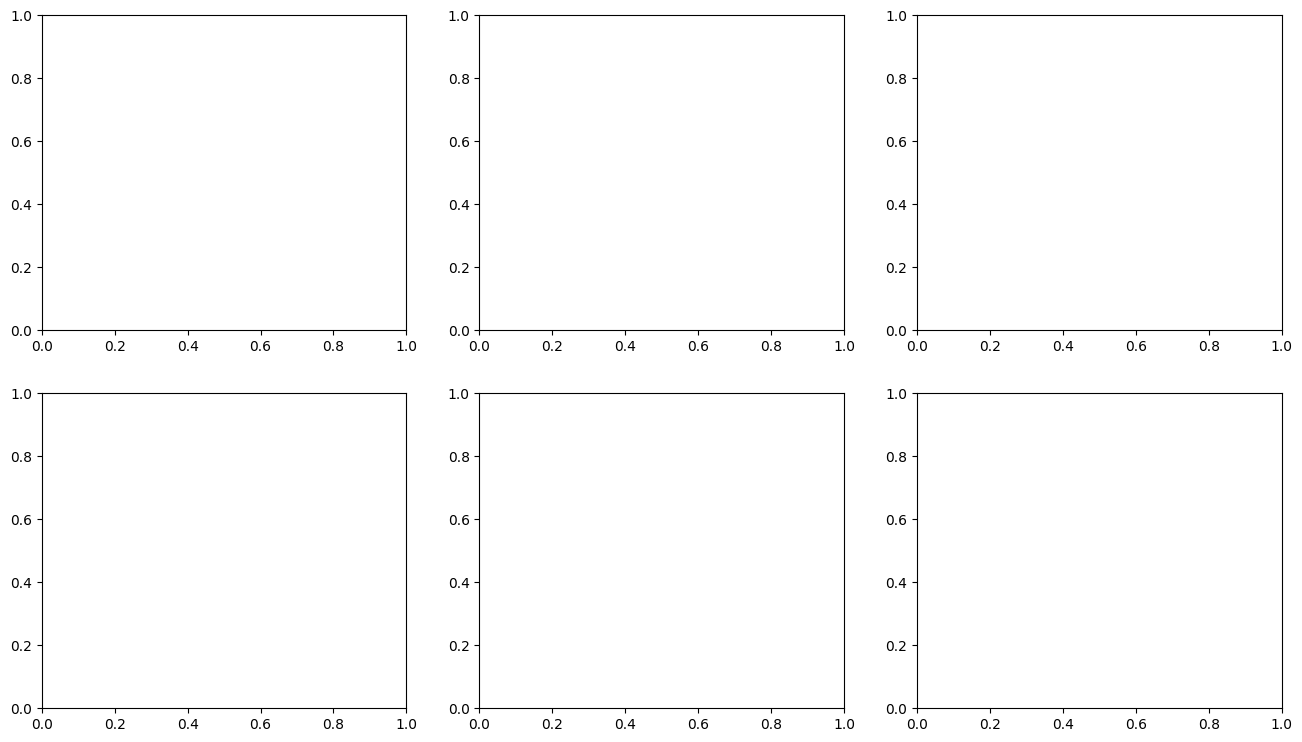

In [43]:
if monitors is None:
    print("no monitor.pkl -> skipping per-episode monitor plots")
else:
    fig, ax = plt.subplots(2, 3, figsize=(16, 9))

    finals = np.array([final_P(b)[0] for b in state_hist])
    ax[0, 0].plot(np.arange(len(finals)), finals, marker="o", label=f"seed {TRAIN_SEED}")
    ax[0, 0].axhline(ref["final_P"], label=ref_lbl, **REF_STYLE)

    yields = []
    for i, m in enumerate(monitors):
        c = _ep_color(i, n_ep)
        ax[0, 1].plot(m["t"], m["PAA"], color=c, lw=1, alpha=.85)
        ax[0, 2].plot(m["t"], m["Viscosity"], color=c, lw=1, alpha=.85)
        ax[1, 0].plot(m["t"], m["Fpaa"], color=c, lw=1, alpha=.85)
        ax[1, 1].plot(m["t"], m["P"], color=c, lw=1, alpha=.85)
        yields.append(yield_kg(m))
    yields = np.array(yields)
    ax[1, 2].bar(np.arange(n_ep), yields, color=[_ep_color(i, n_ep) for i in range(n_ep)])
    ax[1, 2].axhline(ref["yield"], label=ref_lbl, **REF_STYLE)

    for axis, key in [(ax[0, 1], "PAA"), (ax[0, 2], "Viscosity"), (ax[1, 0], "Fpaa"), (ax[1, 1], "P")]:
        if key in ref:
            rt, ry = ref[key]
            axis.plot(rt, ry, label=ref_lbl, **REF_STYLE)

    ax[0, 0].set_title("Final penicillin conc per episode")
    ax[0, 0].set_xlabel("episode (exploration then trials)"); ax[0, 0].set_ylabel("P (g/L)")
    ax[0, 0].grid(alpha=.3); ax[0, 0].legend(fontsize=8)

    ax[0, 1].axhspan(*PAA_BAND, color="green", alpha=.12, label="allowed band")
    ax[0, 1].axvline(WARMUP_H, color="gray", ls=":", label=f"RL on ({WARMUP_H:g} h)")
    ax[0, 1].set_title("PAA conc (all episodes)"); ax[0, 1].set_xlabel("time (h)")
    ax[0, 1].set_ylabel("PAA (mg/L)"); ax[0, 1].grid(alpha=.3); ax[0, 1].legend(fontsize=6, ncol=2)

    ax[0, 2].axhline(VISC_MAX, color="crimson", ls="--", label=f"limit {VISC_MAX:.0f} cP")
    ax[0, 2].axvline(WARMUP_H, color="gray", ls=":", label=f"RL on ({WARMUP_H:g} h)")
    ax[0, 2].set_title("Viscosity (all episodes)"); ax[0, 2].set_xlabel("time (h)")
    ax[0, 2].set_ylabel("viscosity (cP)"); ax[0, 2].grid(alpha=.3); ax[0, 2].legend(fontsize=6, ncol=2)

    ax[1, 0].axvline(WARMUP_H, color="gray", ls=":", label=f"RL on ({WARMUP_H:g} h)")
    ax[1, 0].axhspan(FPAA_MIN, FPAA_MAX, color="orange", alpha=.06,
                     label=f"clamp [{FPAA_MIN:.0f},{FPAA_MAX:.0f}]")
    ax[1, 0].set_title("Fpaa setpoint (all episodes)"); ax[1, 0].set_xlabel("time (h)")
    ax[1, 0].set_ylabel("Fpaa (L/h)"); ax[1, 0].grid(alpha=.3); ax[1, 0].legend(fontsize=6, ncol=2)

    ax[1, 1].axvline(WARMUP_H, color="gray", ls=":", label=f"RL on ({WARMUP_H:g} h)")
    ax[1, 1].set_title("Penicillin trajectories (all episodes)"); ax[1, 1].set_xlabel("time (h)")
    ax[1, 1].set_ylabel("P (g/L)"); ax[1, 1].grid(alpha=.3)
    ax[1, 1].plot([], [], color="0.72", label="exploration")
    _episode_colorbar(fig, ax[1, 1], n_ep, label="trial episode (early -> late)")
    ax[1, 1].legend(fontsize=8)

    ax[1, 2].set_title("Penicillin yield per episode")
    ax[1, 2].set_xlabel("episode"); ax[1, 2].set_ylabel("yield (kg)")
    ax[1, 2].grid(alpha=.3, axis="y"); ax[1, 2].legend(fontsize=8)

    fig.suptitle("Single-run MC-PILCO training progression")
    fig.tight_layout(); plt.show()


## B.2 All observations per episode

One subplot per element of the observation vector (`STATE_NAMES`), every episode overlaid.
Trajectories from `state_samples_history` (normalised) denormalised via `STATE_RANGES`; recipe
reference overlaid where a matching series exists.


KeyError: 'action_ema'

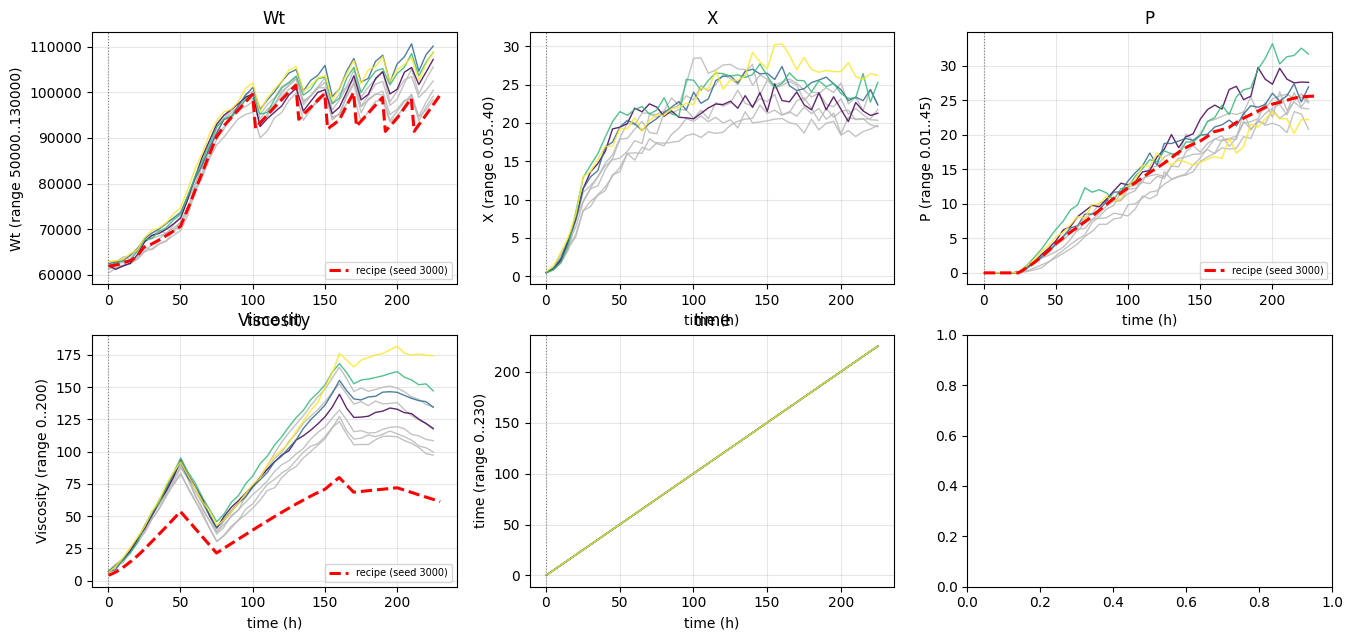

In [ ]:
ncol = 3
n_obs = len(STATE_NAMES)
nrow = int(np.ceil(n_obs / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(16, 3.6 * nrow), squeeze=False)
axes = ax.ravel()
for j, name in enumerate(STATE_NAMES):
    a = axes[j]
    lo, hi = STATE_RANGES[name]
    for i, b in enumerate(state_hist):
        y = _denorm_phys(np.asarray(b)[:, j], name)
        a.plot(decision_time_grid(len(y)), y, color=_ep_color(i, n_ep), lw=1, alpha=.85)
    if name in ref:
        rt, ry = ref[name]
        a.plot(rt, ry, label=ref_lbl, **REF_STYLE)
    if name == "PAA":
        a.axhspan(*PAA_BAND, color="green", alpha=.12, label="allowed band")
    a.axvline(WARMUP_H, color="gray", ls=":", lw=.8)
    _lo_p, _hi_p = decode_state_value(name, lo), decode_state_value(name, hi)
    a.set_title(name); a.set_xlabel("time (h)"); a.set_ylabel(f"{name} (range {_lo_p:g}..{_hi_p:g})")
    a.grid(alpha=.3)
    if name in ref or name == "PAA":
        a.legend(fontsize=7)
axes[0].plot([], [], color="0.72", label="exploration")
_episode_colorbar(fig, list(axes), n_ep, label="trial episode (early -> late)")
axes[0].legend(fontsize=7)
for k in range(n_obs, len(axes)):
    axes[k].axis("off")
fig.suptitle(f"All observations per episode — seed {SEED}", y=1.002)
fig.tight_layout(); plt.show()


## B.3 Fs (sugar feed): recipe vs RL residual, all episodes


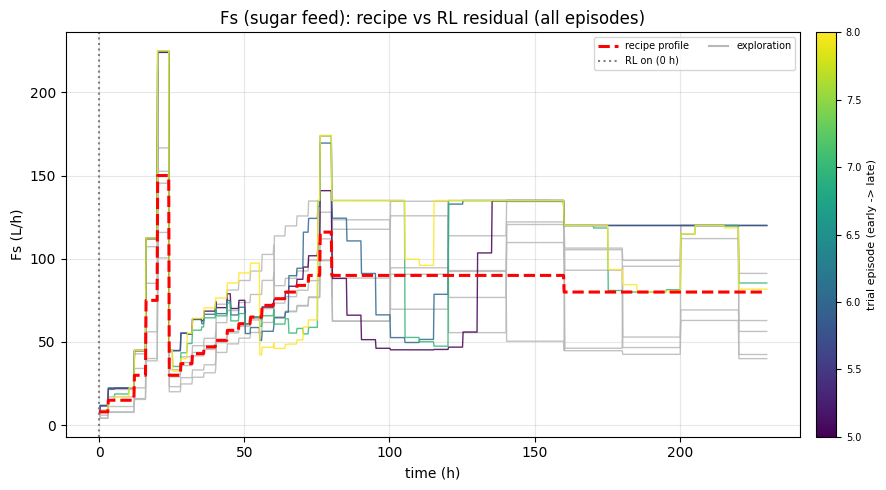

In [ ]:
if monitors is None:
    print("no monitor.pkl -> skipping")
else:
    fs_recipe = Recipe(FS_DEFAULT_PROFILE, FS)
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, m in enumerate(monitors):
        ax.plot(m["t"], m["Fs"], color=_ep_color(i, n_ep), lw=1, alpha=.85)
    t_ref = np.arange(WARMUP_H, 230.0 + STEP_IN_HOURS, STEP_IN_HOURS)
    y_ref = np.array([fs_recipe.get_value_at(float(tt)) for tt in t_ref])
    ax.plot(t_ref, y_ref, label="recipe profile", **REF_STYLE)
    ax.axvline(WARMUP_H, color="gray", ls=":", label=f"RL on ({WARMUP_H:g} h)")
    ax.plot([], [], color="0.72", label="exploration")
    _episode_colorbar(fig, ax, n_ep, label="trial episode (early -> late)")
    ax.set_title("Fs (sugar feed): recipe vs RL residual (all episodes)")
    ax.set_xlabel("time (h)"); ax.set_ylabel("Fs (L/h)")
    ax.grid(alpha=.3); ax.legend(fontsize=7, ncol=2)
    fig.tight_layout(); plt.show()


# C. GP model diagnostics

Is the learned GP dynamics model trustworthy over the horizon MC-PILCO optimises the policy on?
One-step fit, per-dim error, local error across the batch, k-step-ahead growth, and the
short-horizon optimiser-window / recipe-anchor probe. In-sample = the batch the GP trained on;
held-out = the next batch (collected under the trial-idx policy, so it deviates from the recipe).


## C.1 Reconstruct the GP model & score it


In [ ]:
GP_IDX = _resolve_trial(log, GP_TRIAL)
print(f"reconstructing GP model @ trial {GP_IDX} ...")
gp_agent = reconstruct(SEED, NUM_TRIALS, FAST, log, GP_IDX)
ho_idx = GP_IDX + 1
has_ho = ho_idx < len(gp_agent.state_samples_history)
with torch.no_grad():
    _, targets, means, _ = gp_agent.get_model_learning_performance(GP_IDX)
    pred, true, _ = gp_agent.get_rollout_prediction_performance(GP_IDX)
    if has_ho:
        pred_ho, true_ho, _ = gp_agent.get_rollout_prediction_performance(ho_idx)
print("has held-out batch:", has_ho)


reconstructing GP model @ trial 7 ...


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([265, 6])
MSE gp 0:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([425, 6])
MSE gp 1:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([458, 6])
MSE gp 2:  tensor(0.0003, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([495, 6])
MSE gp 3:  tensor(0.0001, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([352, 6])
MSE gp 4:  tensor(3.1352e-

In [ ]:
per_dim_mse = [float(((targets[k] - means[k]) ** 2).mean()) for k in range(len(targets))]
loX, hiX = STATE_RANGES["X"]
loP, hiP = STATE_RANGES["P"]
tgt_dx = _denorm_delta(targets[X_IDX].ravel(), loX, hiX); prd_dx = _denorm_delta(means[X_IDX].ravel(), loX, hiX)
tgt_dp = _denorm_delta(targets[P_IDX].ravel(), loP, hiP); prd_dp = _denorm_delta(means[P_IDX].ravel(), loP, hiP)
r2_x = 1.0 - float(((tgt_dx - prd_dx) ** 2).sum()) / (float(((tgt_dx - tgt_dx.mean()) ** 2).sum()) or 1.0)
r2_p = 1.0 - float(((tgt_dp - prd_dp) ** 2).sum()) / (float(((tgt_dp - tgt_dp.mean()) ** 2).sum()) or 1.0)

gp_inputs = gp_agent.model_learning.data_to_gp_input(
    torch.tensor(gp_agent.state_samples_history[GP_IDX]),
    torch.tensor(gp_agent.input_samples_history[GP_IDX]))[:-1, :].detach().cpu().numpy()
action_col = gp_inputs[:, ACTION_IDX]

t_ms = decision_time_grid(pred.shape[0])
x_pred = _denorm_phys(pred[:, X_IDX], "X"); x_true = _denorm_phys(true[:, X_IDX], "X")
p_pred = _denorm_phys(pred[:, P_IDX], "P"); p_true = _denorm_phys(true[:, P_IDX], "P")
if has_ho:
    t_ho = decision_time_grid(pred_ho.shape[0])
    x_pred_ho = _denorm_phys(pred_ho[:, X_IDX], "X"); x_true_ho = _denorm_phys(true_ho[:, X_IDX], "X")
    p_pred_ho = _denorm_phys(pred_ho[:, P_IDX], "P"); p_true_ho = _denorm_phys(true_ho[:, P_IDX], "P")
print(f"one-step R^2: X={r2_x:.3f}  P={r2_p:.3f}")


one-step R^2: X=0.928  P=0.971


## C.2 One-step fit, per-dim MSE, multi-step X & P rollouts (in-sample vs held-out)


NameError: name 'tgt_dx' is not defined

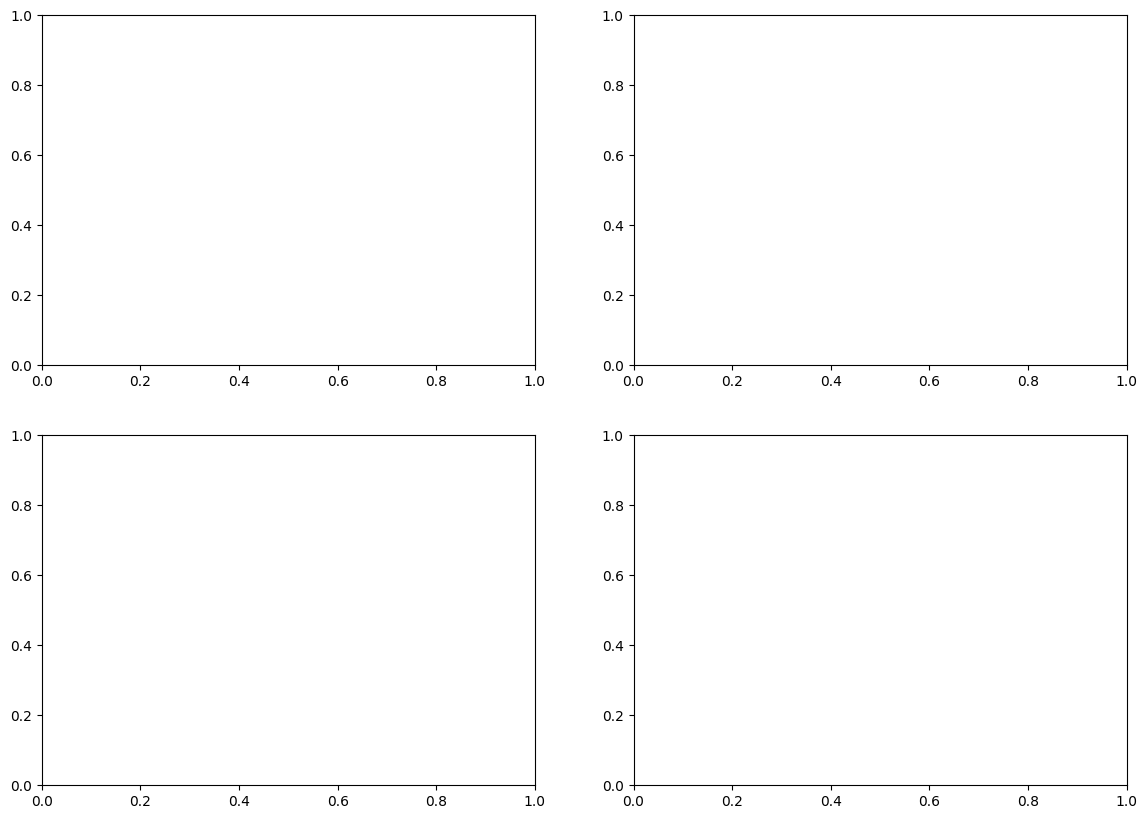

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sc = ax[0, 0].scatter(tgt_dx, prd_dx, c=action_col, cmap="viridis", s=14, alpha=.8)
lim = [min(tgt_dx.min(), prd_dx.min()), max(tgt_dx.max(), prd_dx.max())]
ax[0, 0].plot(lim, lim, "r--", lw=1.5, label="perfect (y=x)")
fig.colorbar(sc, ax=ax[0, 0], label="Fs action (-1..+1)")
ax[0, 0].set_title(f"One-step dX: GP vs actual (R^2={r2_x:.3f}, in-sample)")
ax[0, 0].set_xlabel("actual dX (g/L per step)"); ax[0, 0].set_ylabel("GP predicted dX")
ax[0, 0].grid(alpha=.3); ax[0, 0].legend(fontsize=8)

ax[0, 1].bar(range(len(per_dim_mse)), per_dim_mse, color="steelblue")
ax[0, 1].bar([X_IDX], [per_dim_mse[X_IDX]], color="crimson", label="X")
ax[0, 1].bar([P_IDX], [per_dim_mse[P_IDX]], color="darkorange", label="P")
ax[0, 1].set_xticks(range(len(STATE_NAMES))); ax[0, 1].set_xticklabels(STATE_NAMES, rotation=45)
ax[0, 1].set_title("Per-dim one-step MSE (normalised delta)"); ax[0, 1].set_ylabel("MSE")
ax[0, 1].grid(alpha=.3, axis="y"); ax[0, 1].legend(fontsize=8)

ax[1, 0].plot(t_ms, x_true, "k-", lw=2, label=f"in-sample true (batch {GP_IDX})")
ax[1, 0].plot(t_ms, x_pred, "C1--", lw=2, label="in-sample GP")
if has_ho:
    ax[1, 0].plot(t_ho, x_true_ho, "-", color="steelblue", lw=2, label=f"held-out true (batch {ho_idx})")
    ax[1, 0].plot(t_ho, x_pred_ho, "--", color="crimson", lw=2, label="held-out GP")
ax[1, 0].set_title("Multi-step X (biomass): in-sample vs held-out")
ax[1, 0].set_xlabel("time (h)"); ax[1, 0].set_ylabel("X (g/L)"); ax[1, 0].grid(alpha=.3)
axt = ax[1, 0].twinx(); axt.set_ylabel("Fs (L/h)", color="purple"); axt.set_xlim(t_ms[0], t_ms[-1])
grid = monitors[GP_IDX]["t"] if monitors is not None else t_ms
recipe_fs = [gp_agent.system._recipe.get_values_dict_at(time=float(tt))[FS] for tt in grid]
axt.plot(grid, recipe_fs, color="gray", ls="--", lw=1.2, alpha=.6, label="recipe Fs (a=0)")
if monitors is not None:
    axt.plot(monitors[GP_IDX]["t"], monitors[GP_IDX]["Fs"], color="C1", ls=":", lw=1.2, alpha=.6,
             label="Fs in-sample")
    if has_ho and ho_idx < len(monitors):
        axt.plot(monitors[ho_idx]["t"], monitors[ho_idx]["Fs"], color="crimson", ls=":", lw=1.2,
                 alpha=.6, label="Fs held-out")
h1, l1 = ax[1, 0].get_legend_handles_labels(); h2, l2 = axt.get_legend_handles_labels()
ax[1, 0].legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")

ax[1, 1].plot(t_ms, p_true, "k-", lw=2, label=f"in-sample true (batch {GP_IDX})")
ax[1, 1].plot(t_ms, p_pred, "C1--", lw=2, label="in-sample GP")
if has_ho:
    ax[1, 1].plot(t_ho, p_true_ho, "-", color="steelblue", lw=2, label=f"held-out true (batch {ho_idx})")
    ax[1, 1].plot(t_ho, p_pred_ho, "--", color="crimson", lw=2, label="held-out GP")
ax[1, 1].set_title("Multi-step P: in-sample vs held-out")
ax[1, 1].set_xlabel("time (h)"); ax[1, 1].set_ylabel("P (g/L)"); ax[1, 1].grid(alpha=.3); ax[1, 1].legend(fontsize=8)

fig.suptitle(f"GP-vs-simulator diagnostic — seed {SEED}, model@trial {GP_IDX}"
             + (f" (held-out batch {ho_idx})" if has_ho else " (in-sample only)"))
fig.tight_layout(); plt.show()

print(f"X rollout in-sample: final actual={x_true[-1]:.2f} g/L, GP={x_pred[-1]:.2f} g/L")
print(f"P rollout in-sample: final actual={p_true[-1]:.2f} g/L, GP={p_pred[-1]:.2f} g/L")
if has_ho:
    print(f"X rollout held-out : final actual={x_true_ho[-1]:.2f} g/L, GP={x_pred_ho[-1]:.2f} g/L")
    print(f"P rollout held-out : final actual={p_true_ho[-1]:.2f} g/L, GP={p_pred_ho[-1]:.2f} g/L")


## C.2b GP multi-step uncertainty — all channels, with the model's own uncertainty

C.2 draws the GP's **deterministic mean rollout** (`particle_pred=False`): it feeds its own mean
prediction back into itself, step after step. That is a **single path** — and it is the path MC-PILCO's
policy optimiser plans against.

This cell keeps **that same line** for **every state channel**, and adds:

- the **particle band** (N particles, `particle_pred=True`, sampling `delta ~ N(mean, var)` each step)
  — how uncertainty *compounds* over the horizon;
- the **particle median** — a *robust* statistic; runaway particles don't drag a median.

**The gap between the mean path and the particle median is diagnostic**: a large gap means the mean
rollout the optimiser trusts is not representative of the model's own distribution.

**Axes are locked** — every panel shares the same time axis, and each channel shares one y-range across
in-sample and held-out — so the two columns are directly comparable. The y-range is the channel's
declared `STATE_RANGES` (its physically meaningful span), so where the GP leaves physical bounds it is
**clipped at the frame edge** and the true extent is printed below.

**Coverage** is the calibration check: a 10–90% band should contain the truth ~80% of the time.


In [ ]:
_N_PART = 100

def _particle_rollout(agent, idx, N=_N_PART, seed=0):
    """N particles through the RECORDED action sequence of batch `idx` (particle_pred=True ->
    each step samples delta ~ N(mean, var)). Same machinery MC-PILCO uses in policy optimisation."""
    ml = agent.model_learning
    ml.set_eval_mode()
    S = np.asarray(agent.state_samples_history[idx])
    U = np.asarray(agent.input_samples_history[idx])
    T, D = S.shape
    torch.manual_seed(seed)
    x = torch.tensor(np.tile(S[0], (N, 1)), dtype=agent.dtype, device=agent.device)
    out = np.zeros((T, N, D)); out[0] = x.detach().cpu().numpy()
    with torch.no_grad():
        for t in range(1, T):
            u = torch.tensor(np.tile(U[t - 1], (N, 1)), dtype=agent.dtype, device=agent.device)
            x, _, _ = ml.get_next_state(current_state=x, current_input=u, particle_pred=True)
            out[t] = x.detach().cpu().numpy()
    return out

_cols = [(GP_IDX, "IN-SAMPLE", pred)]
if has_ho:
    _cols.append((ho_idx, "HELD-OUT", pred_ho))

_tr = {idx: _particle_rollout(gp_agent, idx) for idx, _, _ in _cols}
_t = {idx: decision_time_grid(_tr[idx].shape[0]) for idx, _, _ in _cols}

_xlim = (min(_t[i][0] for i, _, _ in _cols), max(_t[i][-1] for i, _, _ in _cols))

_nrow, _ncol = len(STATE_NAMES), len(_cols)
fig, ax = plt.subplots(_nrow, _ncol, figsize=(7.0 * _ncol, 2.5 * _nrow), squeeze=False)

print(f"{'channel':>10} {'batch':>10} | {'coverage':>9} {'|mean-median|':>14} | band beyond physical range?")
for _r, _name in enumerate(STATE_NAMES):
    _k = STATE_NAMES.index(_name)
    _lo, _hi = STATE_RANGES[_name]
    _lo_p, _hi_p = decode_state_value(_name, _lo), decode_state_value(_name, _hi)
    _pad = 0.05 * (_hi_p - _lo_p)
    for _c, (_bidx, _tag, _meanroll) in enumerate(_cols):
        v = _denorm_phys(_tr[_bidx][:, :, _k], _name)
        p10, p50, p90 = (np.percentile(v, 10, axis=1), np.median(v, axis=1),
                         np.percentile(v, 90, axis=1))
        truth = _denorm_phys(np.asarray(gp_agent.state_samples_history[_bidx])[:, _k], _name)
        mline = _denorm_phys(np.asarray(_meanroll)[:, _k], _name)
        tt = _t[_bidx]
        a = ax[_r, _c]
        a.fill_between(tt, p10, p90, color="C0", alpha=.22, label=f"GP 10-90% ({_N_PART} particles)")
        a.plot(tt, truth, "k-", lw=1.8, label="simulator (truth)")
        a.plot(tt, mline, "C1--", lw=1.8, label="GP mean rollout (= C.2)")
        a.plot(tt, p50, "C0-", lw=1.5, label="GP particle median")
        a.set_xlim(*_xlim)
        a.set_ylim(_lo_p - _pad, _hi_p + _pad)
        a.set_title(f"{_name} - {_tag} (batch {_bidx})", fontsize=9)
        a.set_ylabel(_name, fontsize=8); a.grid(alpha=.3)
        a.tick_params(labelsize=7)
        if _r == _nrow - 1:
            a.set_xlabel("time (h)", fontsize=8)
        if _r == 0 and _c == 0:
            a.legend(fontsize=6.5, loc="upper left")

        cov = float(np.mean((truth >= p10) & (truth <= p90)))
        gap = abs(float(mline[-1]) - float(p50[-1]))
        out = (p10.min() < _lo_p - _pad) or (p90.max() > _hi_p + _pad)
        note = f"YES  band=[{p10.min():.1f}, {p90.max():.1f}] vs range [{_lo_p:g}, {_hi_p:g}]" if out else "no"
        print(f"{_name:>10} {_tag:>10} | {100*cov:>8.1f}% {gap:>14.3f} | {note}")

fig.suptitle(f"C.2b - GP multi-step uncertainty, all channels (locked axes) - seed {SEED}, model@trial {GP_IDX}",
             y=1.001)
fig.tight_layout(); plt.show()
print("\ncoverage << 80%      => GP overconfident.   coverage ~100% with a huge band => 'I don't know'.")
print("large mean-median gap => the mean path the optimiser plans against is NOT representative")
print("                         of the model's own distribution.")
print("band beyond physical range => the GP is predicting states the reactor cannot occupy.")


NameError: name 'GP_IDX' is not defined

## C.3 One-step dP scatter (R² for penicillin — the reward channel)


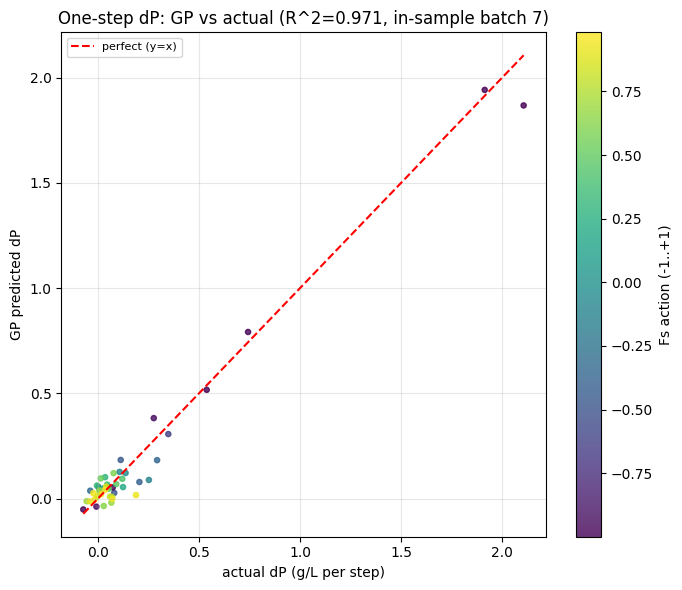

P one-step R^2=0.9712  |  X one-step R^2=0.9283


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(tgt_dp, prd_dp, c=action_col, cmap="viridis", s=14, alpha=.8)
lim = [min(tgt_dp.min(), prd_dp.min()), max(tgt_dp.max(), prd_dp.max())]
ax.plot(lim, lim, "r--", lw=1.5, label="perfect (y=x)")
fig.colorbar(sc, ax=ax, label="Fs action (-1..+1)")
ax.set_title(f"One-step dP: GP vs actual (R^2={r2_p:.3f}, in-sample batch {GP_IDX})")
ax.set_xlabel("actual dP (g/L per step)"); ax.set_ylabel("GP predicted dP")
ax.grid(alpha=.3); ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print(f"P one-step R^2={r2_p:.4f}  |  X one-step R^2={r2_x:.4f}")


## C.4 Per-dim one-step model quality (comparable across dims)


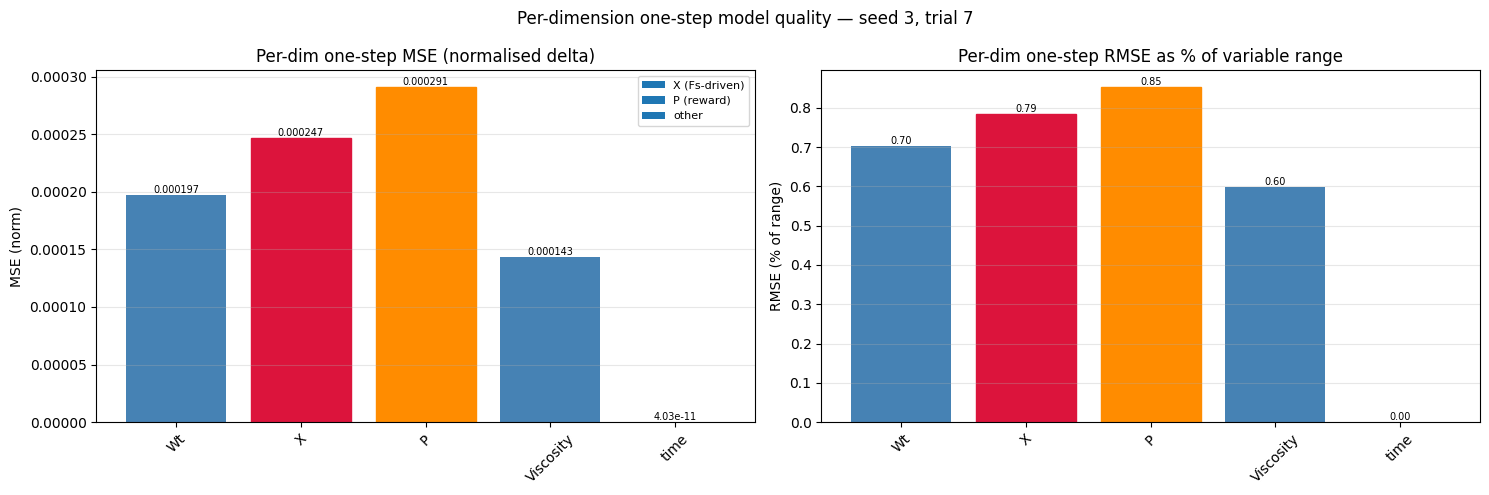

       dim   MSE(norm)  RMSE(%range)   RMSE(phys)
        Wt    1.97e-04         0.70%     0.006714
         X    2.47e-04         0.79%       0.0525
         P    2.91e-04         0.85%      0.07173
 Viscosity    1.43e-04         0.60%        1.196
      time    4.03e-11         0.00%    0.0007297


In [ ]:
rmse_norm = np.sqrt(np.asarray(per_dim_mse))
rmse_pct = rmse_norm * 50.0
rmse_phys = np.array([_denorm_delta(rmse_norm[k], *STATE_RANGES[n]) for k, n in enumerate(STATE_NAMES)])

def _bars(a, vals, title, ylabel, fmt="{:.3g}"):
    bars = a.bar(range(len(vals)), vals, color="steelblue")
    bars[X_IDX].set_color("crimson"); bars[P_IDX].set_color("darkorange")
    a.set_xticks(range(len(STATE_NAMES))); a.set_xticklabels(STATE_NAMES, rotation=45)
    a.set_title(title); a.set_ylabel(ylabel); a.grid(alpha=.3, axis="y")
    for j, v in enumerate(vals):
        a.annotate(fmt.format(v), (j, v), ha="center", va="bottom", fontsize=7)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
_bars(ax[0], per_dim_mse, "Per-dim one-step MSE (normalised delta)", "MSE (norm)")
_bars(ax[1], rmse_pct, "Per-dim one-step RMSE as % of variable range", "RMSE (% of range)", "{:.2f}")
for c, lbl in [("crimson", "X (Fs-driven)"), ("darkorange", "P (reward)"), ("steelblue", "other")]:
    ax[0].bar([], [], color=c, label=lbl)
ax[0].legend(fontsize=8)
fig.suptitle(f"Per-dimension one-step model quality — seed {SEED}, trial {GP_IDX}")
fig.tight_layout(); plt.show()

print(f"{'dim':>10} {'MSE(norm)':>11} {'RMSE(%range)':>13} {'RMSE(phys)':>12}")
for k, name in enumerate(STATE_NAMES):
    print(f"{name:>10} {per_dim_mse[k]:>11.2e} {rmse_pct[k]:>12.2f}% {rmse_phys[k]:>12.4g}")


## C.4b One-step teacher-forced standardised residuals (per channel — GP calibration)

**What this checks (distinct from C.3/C.4, which only score the mean):** feed each GP the *true*
state at every decision step `t` (teacher forcing — no error accumulation), predict a single
one-step `Δ` with its **predictive variance**, and compare to the true `Δ`. Report the
**standardised** residual per channel

  `z = (predicted_next − true_next) / pred_std`   (normalised state space)

If the GP's *uncertainty* is honest, each channel's `z` should be ~ **N(0, 1)**: mean ≈ 0
(unbiased), std ≈ 1 (variance neither over- nor under-confident), and ~95% of points within
±1.96. std ≫ 1 → the GP is over-confident (real errors bigger than its error bars);
std ≪ 1 → under-confident. This is the one-step analogue of C.2b's multi-step band coverage.

*Note:* the `time` channel is a deterministic clock (variance pinned to a tiny jitter), so its
`z` is ~0 by construction and is **not** a meaningful calibration target — ignore it here.

 channel      batch |    mean     std  |z|<1.96   (ideal: 0.0, 1.0, ~95%)
      Wt  in-sample |   0.499   3.727     35.6%
      Wt   held-out |   0.300   3.615     42.2%
       X  in-sample |  -2.265   3.281     37.8%
       X   held-out |  -1.061   3.998     46.7%
       P  in-sample |  -0.393   2.590     62.2%
       P   held-out |  -0.243   2.273     55.6%
Viscosity  in-sample |  -0.159   1.564     84.4%
Viscosity   held-out |  -0.058   2.104     64.4%
    time  in-sample |  -0.000   0.000    100.0%
    time   held-out |  -0.000   0.000    100.0%


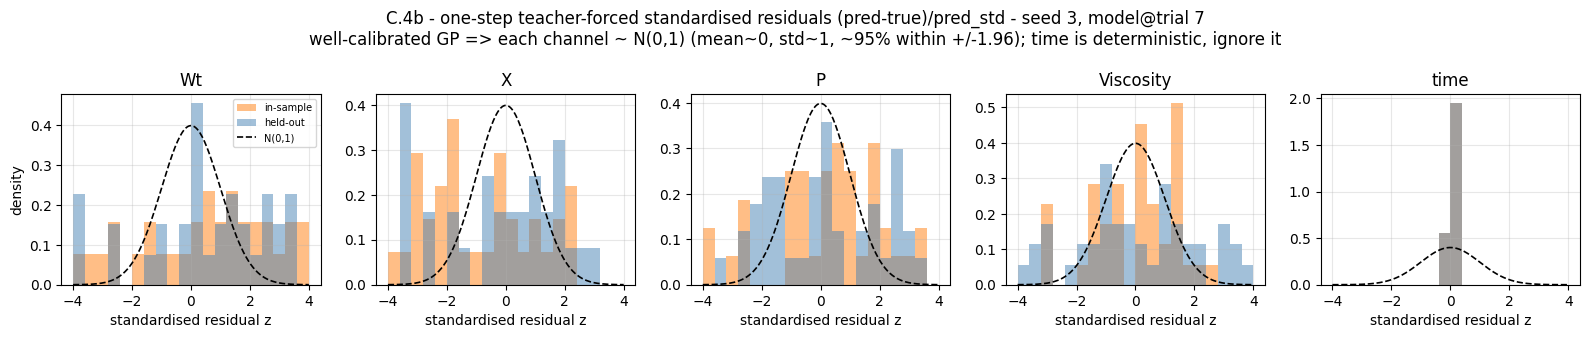

In [ ]:
def _one_step_std_residuals(batch_idx):
    """Teacher-forced one-step standardised residuals, per channel (normalised state space).

    Feed the TRUE state at each t (particle_pred=False -> deterministic mean prediction), read the
    GP's predictive mean+variance for the single-step delta, and standardise the residual by the
    GP's own predictive std. Returns z[N-1, STATE_DIM]; a well-calibrated channel => z ~ N(0,1).
    (nxt - true_next) == (pred_delta - true_delta) since both share the same true current state."""
    ml = gp_agent.model_learning
    tr = torch.tensor(gp_agent.state_samples_history[batch_idx], dtype=gp_agent.dtype, device=gp_agent.device)
    ip = torch.tensor(gp_agent.input_samples_history[batch_idx], dtype=gp_agent.dtype, device=gp_agent.device)
    N = tr.shape[0]
    z = np.full((N - 1, STATE_DIM), np.nan)
    with torch.no_grad():
        for t0 in range(N - 1):
            nxt, _dmean, dvar = ml.get_next_state(current_state=tr[t0:t0 + 1, :],
                                                  current_input=ip[t0:t0 + 1, :], particle_pred=False)
            std = torch.sqrt(dvar).ravel()
            resid = (nxt - tr[t0 + 1:t0 + 2, :]).ravel()
            z[t0] = (resid / std).detach().cpu().numpy()
    return z


_zin = _one_step_std_residuals(GP_IDX)
_zho = _one_step_std_residuals(ho_idx) if has_ho else None

_xg = np.linspace(-4, 4, 200)
_npdf = np.exp(-_xg ** 2 / 2) / np.sqrt(2 * np.pi)

fig, ax = plt.subplots(1, STATE_DIM, figsize=(3.2 * STATE_DIM, 3.4), squeeze=False)
print(f"{'channel':>8} {'batch':>10} | {'mean':>7} {'std':>7} {'|z|<1.96':>9}   (ideal: 0.0, 1.0, ~95%)")
_series = [(_zin, "in-sample", "C1")] + ([(_zho, "held-out", "steelblue")] if has_ho else [])
for _k, _name in enumerate(STATE_NAMES):
    a = ax[0, _k]
    for _z, _tag, _col in _series:
        zc = _z[:, _k]; zc = zc[np.isfinite(zc)]
        if zc.size == 0:
            continue
        a.hist(zc, bins=20, range=(-4, 4), density=True, alpha=.5, color=_col, label=_tag)
        cov = float(np.mean(np.abs(zc) < 1.96))
        print(f"{_name:>8} {_tag:>10} | {zc.mean():>7.3f} {zc.std():>7.3f} {cov * 100:>8.1f}%")
    a.plot(_xg, _npdf, "k--", lw=1.2, label="N(0,1)")
    a.set_title(_name); a.set_xlabel("standardised residual z"); a.grid(alpha=.3)
    if _k == 0:
        a.set_ylabel("density"); a.legend(fontsize=7)
fig.suptitle(f"C.4b - one-step teacher-forced standardised residuals (pred-true)/pred_std - "
             f"seed {SEED}, model@trial {GP_IDX}\n"
             "well-calibrated GP => each channel ~ N(0,1) (mean~0, std~1, ~95% within +/-1.96); "
             "time is deterministic, ignore it")
fig.tight_layout(); plt.show()


## C.5 Local (one-step) error across the batch

Each estimate re-anchors on the truth, so there is no accumulation — the only thing varying with
batch time is how good the GP is at that operating point. Flat ⇒ late rollout divergence is pure
accumulation; growing late ⇒ a local model-quality problem (discharge pulses, stationary phase).


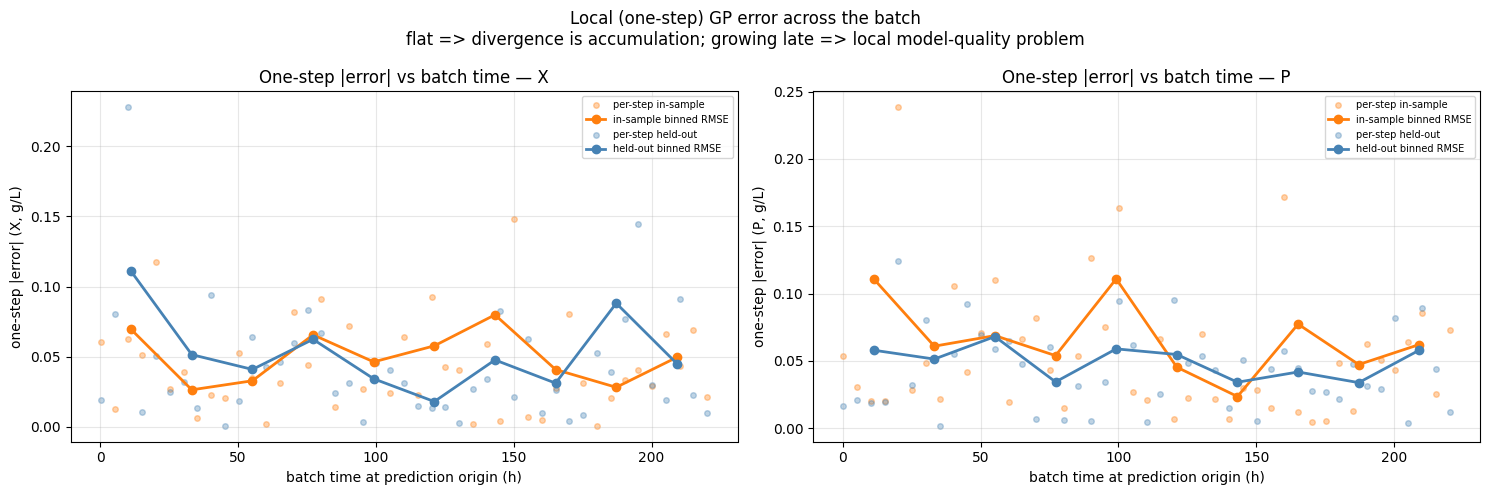

In [ ]:
def _one_step_abs_err(batch_idx):
    ml = gp_agent.model_learning
    tr = torch.tensor(gp_agent.state_samples_history[batch_idx], dtype=gp_agent.dtype, device=gp_agent.device)
    ip = torch.tensor(gp_agent.input_samples_history[batch_idx], dtype=gp_agent.dtype, device=gp_agent.device)
    N = tr.shape[0]
    grid = decision_time_grid(N)
    errs = np.full((N - 1, STATE_DIM), np.nan)
    with torch.no_grad():
        for t0 in range(N - 1):
            nxt, _, _ = ml.get_next_state(current_state=tr[t0:t0 + 1, :],
                                          current_input=ip[t0:t0 + 1, :], particle_pred=False)
            errs[t0] = (nxt - tr[t0 + 1:t0 + 2, :]).abs().ravel().detach().cpu().numpy()
    eX = _denorm_delta(errs[:, X_IDX], *STATE_RANGES["X"])
    eP = _denorm_delta(errs[:, P_IDX], *STATE_RANGES["P"])
    return grid[:-1], eX, eP

t_in, eX_in, eP_in = _one_step_abs_err(GP_IDX)
if has_ho:
    t_ho2, eX_ho, eP_ho = _one_step_abs_err(ho_idx)

nbins = min(10, len(t_in))
edges = np.linspace(t_in.min(), t_in.max(), nbins + 1)
bc = 0.5 * (edges[:-1] + edges[1:])
def _rmse_by_bin(tt, e):
    b = np.clip(np.digitize(tt, edges) - 1, 0, nbins - 1)
    return np.array([np.sqrt((e[b == k] ** 2).mean()) if (b == k).any() else np.nan for k in range(nbins)])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for a, name, ein, eho in [(ax[0], "X", eX_in, eX_ho if has_ho else None),
                          (ax[1], "P", eP_in, eP_ho if has_ho else None)]:
    a.scatter(t_in, ein, s=16, alpha=.35, color="C1", label="per-step in-sample")
    a.plot(bc, _rmse_by_bin(t_in, ein), "-o", color="C1", lw=2, label="in-sample binned RMSE")
    if has_ho:
        a.scatter(t_ho2, eho, s=16, alpha=.35, color="steelblue", label="per-step held-out")
        a.plot(bc, _rmse_by_bin(t_ho2, eho), "-o", color="steelblue", lw=2, label="held-out binned RMSE")
    a.set_title(f"One-step |error| vs batch time — {name}")
    a.set_xlabel("batch time at prediction origin (h)"); a.set_ylabel(f"one-step |error| ({name}, g/L)")
    a.grid(alpha=.3); a.legend(fontsize=7)
fig.suptitle("Local (one-step) GP error across the batch\n"
             "flat => divergence is accumulation; growing late => local model-quality problem")
fig.tight_layout(); plt.show()


## C.6 k-step-ahead prediction error growth


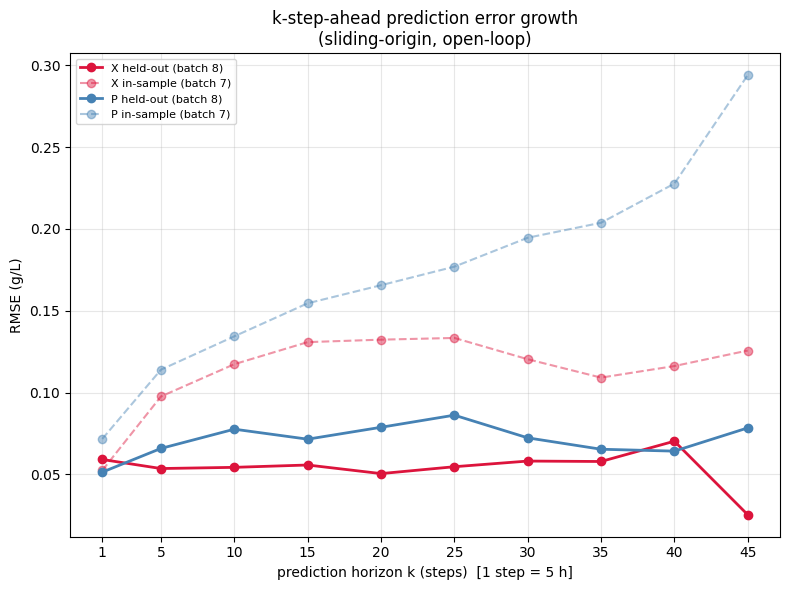

   k       h |     X in   X held |     P in   P held   (g/L)
   1     5.0 |    0.052    0.059 |    0.072    0.051
   5    25.0 |    0.098    0.054 |    0.114    0.066
  10    50.0 |    0.117    0.054 |    0.134    0.078
  15    75.0 |    0.131    0.056 |    0.155    0.072
  20   100.0 |    0.132    0.051 |    0.166    0.079
  25   125.0 |    0.133    0.055 |    0.177    0.086
  30   150.0 |    0.120    0.058 |    0.195    0.072
  35   175.0 |    0.109    0.058 |    0.204    0.065
  40   200.0 |    0.116    0.070 |    0.228    0.064
  45   225.0 |    0.126    0.025 |    0.294    0.078


In [ ]:
KSTEP_HORIZONS = (1, 5, 10, 15, 20, 25, 30, 35, 40, 45)
Tb = gp_agent.state_samples_history[GP_IDX].shape[0]
horizons = np.array([k for k in KSTEP_HORIZONS if 1 <= k <= Tb - 1])
rmse_in = _kstep_errors(gp_agent, GP_IDX, horizons)
rmse_ho = _kstep_errors(gp_agent, ho_idx, horizons) if has_ho else None

fig, ax = plt.subplots(figsize=(8, 6))
for dim, name, color in [(X_IDX, "X", "crimson"), (P_IDX, "P", "steelblue")]:
    lo, hi = STATE_RANGES[name]
    if has_ho:
        y = _denorm_delta(rmse_ho[:, dim], lo, hi); m = np.isfinite(y)
        ax.plot(horizons[m], y[m], "-o", color=color, lw=2, label=f"{name} held-out (batch {ho_idx})")
    y = _denorm_delta(rmse_in[:, dim], lo, hi); m = np.isfinite(y)
    ax.plot(horizons[m], y[m], "--o", color=color, lw=1.5, alpha=.45,
            label=f"{name} in-sample (batch {GP_IDX})")
ax.set_xscale("linear"); ax.set_xticks(horizons); ax.set_xticklabels([str(k) for k in horizons])
ax.set_xlabel(f"prediction horizon k (steps)  [1 step = {T_SAMPLING:g} h]"); ax.set_ylabel("RMSE (g/L)")
ax.set_title("k-step-ahead prediction error growth\n(sliding-origin, open-loop)")
ax.grid(alpha=.3, which="both"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"{'k':>4} {'h':>7} | {'X in':>8} {'X held':>8} | {'P in':>8} {'P held':>8}   (g/L)")
for r, k in enumerate(horizons):
    xi = _denorm_delta(rmse_in[r, X_IDX], *STATE_RANGES["X"]); pi = _denorm_delta(rmse_in[r, P_IDX], *STATE_RANGES["P"])
    xh = _denorm_delta(rmse_ho[r, X_IDX], *STATE_RANGES["X"]) if has_ho else float("nan")
    ph = _denorm_delta(rmse_ho[r, P_IDX], *STATE_RANGES["P"]) if has_ho else float("nan")
    print(f"{k:>4} {k * T_SAMPLING:>7.1f} | {xi:>8.3f} {xh:>8.3f} | {pi:>8.3f} {ph:>8.3f}")


## C.7 Short-horizon diagnostic (optimiser window & recipe anchors)

With the multi-origin short-horizon update, the policy is optimised over many short H-step
rollouts launched from recipe anchors, not one long rollout. This probes: (top-left) error growth
inside vs beyond the H-step optimiser window; (top-right) per-anchor H-step accuracy by batch phase;
(bottom) each anchor's H-step pure-GP rollout over the true recipe trajectory (dot = the only point
truth is injected). Guarded, so it is skipped cleanly if the run lacks the required attributes.


In [ ]:
def _recipe_batch(agent, seed):
    w = PenSimWrapper(seed_offset=agent.system.seed_offset)
    a0 = lambda state, decision_idx: np.array([0.0])
    states, inputs, _ = w.rollout(s0=initial_state_norm(), policy=a0, T=CONTROL_H,
                                  dt=agent.T_sampling, noise=agent.std_meas_noise, seed=seed)
    return states, inputs


def _window_rollouts(agent, true, inp, origins, H):
    ml = agent.model_learning
    true_t = torch.tensor(true, dtype=agent.dtype, device=agent.device)
    inp_t = torch.tensor(inp, dtype=agent.dtype, device=agent.device)
    T = true_t.shape[0]
    preds, rmseH = [], []
    for t0 in origins:
        h = int(min(H, T - 1 - t0))
        cur = true_t[t0:t0 + 1, :]
        traj, sq = [cur], []
        for j in range(1, h + 1):
            cur, _, _ = ml.get_next_state(current_state=cur,
                                          current_input=inp_t[t0 + j - 1:t0 + j, :], particle_pred=False)
            traj.append(cur)
            sq.append(((cur - true_t[t0 + j:t0 + j + 1, :]).ravel() ** 2).detach().cpu().numpy())
        preds.append(torch.cat(traj, 0).detach().cpu().numpy())
        rmseH.append(np.sqrt(np.mean(np.stack(sq, 0), axis=0)) if sq else np.full(STATE_DIM, np.nan))
    return preds, np.stack(rmseH)


try:
    if not (OPTIM_HORIZON and NUM_ANCHORS):
        raise RuntimeError(f"disabled by config (OPTIM_HORIZON={OPTIM_HORIZON}, NUM_ANCHORS={NUM_ANCHORS})")
    H = int(OPTIM_HORIZON)
    horizons2 = np.array(sorted({k for k in (1, 5, 10, 15, 20, H, int(1.5 * H), 2 * H, 50)
                                 if 1 <= k <= Tb - 1}))
    rmse_in2 = _kstep_errors(gp_agent, GP_IDX, horizons2)
    rmse_ho2 = _kstep_errors(gp_agent, ho_idx, horizons2) if has_ho else None

    rs, ri = _recipe_batch(gp_agent, gp_agent.system.seed_offset)
    Tr = rs.shape[0]
    anchor_t0 = np.linspace(0, max(1, Tr - 1 - H), NUM_ANCHORS).round().astype(int)
    preds_a, rmseH = _window_rollouts(gp_agent, rs, ri, anchor_t0, H)
    anchor_hours = WARMUP_H + anchor_t0 * T_SAMPLING
    xH = _denorm_delta(rmseH[:, X_IDX], *STATE_RANGES["X"])
    pH = _denorm_delta(rmseH[:, P_IDX], *STATE_RANGES["P"])

    fig, ax = plt.subplots(2, 2, figsize=(14, 10)); hcol = "purple"

    a00 = ax[0, 0]
    for dim, name, color in [(X_IDX, "X", "crimson"), (P_IDX, "P", "steelblue")]:
        if has_ho:
            y = _denorm_delta(rmse_ho2[:, dim], *STATE_RANGES[name]); m = np.isfinite(y)
            a00.plot(horizons2[m], y[m], "-o", color=color, lw=2, label=f"{name} held-out")
        y = _denorm_delta(rmse_in2[:, dim], *STATE_RANGES[name]); m = np.isfinite(y)
        a00.plot(horizons2[m], y[m], "--o", color=color, lw=1.4, alpha=.45, label=f"{name} in-sample")
    a00.axvspan(horizons2.min(), H, color="green", alpha=.06)
    a00.axvline(H, color=hcol, ls=":", lw=1.6, label=f"optimiser horizon H={H}")
    a00.set_xlabel(f"horizon k (steps)  [1 step = {T_SAMPLING:g} h]"); a00.set_ylabel("RMSE (g/L)")
    a00.set_title(f"Error growth: inside (green) vs beyond the H={H} optimiser window")
    a00.grid(alpha=.3); a00.legend(fontsize=7)

    a01 = ax[0, 1]
    a01.plot(anchor_hours, xH, "-o", color="crimson", lw=2, label="X")
    a01.plot(anchor_hours, pH, "-o", color="steelblue", lw=2, label="P")
    a01.set_xlabel("anchor launch time (h)"); a01.set_ylabel(f"{H}-step-window RMSE (g/L)")
    a01.set_title(f"Per-anchor {H}-step accuracy across the batch")
    a01.grid(alpha=.3); a01.legend(fontsize=8)

    norm = plt.Normalize(vmin=float(anchor_hours.min()), vmax=float(anchor_hours.max()))
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm); sm.set_array([])
    for a1, dim, name in [(ax[1, 0], X_IDX, "X"), (ax[1, 1], P_IDX, "P")]:
        t_full = WARMUP_H + np.arange(Tr) * T_SAMPLING
        true_phys = _denorm_phys(rs[:, dim], name)
        (rl,) = a1.plot(t_full, true_phys, "k-", lw=2, label="recipe true", zorder=3)
        for a, t0 in enumerate(anchor_t0):
            c = plt.cm.viridis(norm(anchor_hours[a]))
            tw = WARMUP_H + (t0 + np.arange(preds_a[a].shape[0])) * T_SAMPLING
            a1.plot(tw, _denorm_phys(preds_a[a][:, dim], name), "-", color=c, lw=1.6, alpha=.9)
            a1.axvline(anchor_hours[a], color="0.7", ls=":", lw=.6, alpha=.5, zorder=0)
            a1.plot(anchor_hours[a], true_phys[t0], "o", color=c, ms=5, mec="k", mew=.5, zorder=4)
        a1.set_xlabel("time (h)"); a1.set_ylabel(f"{name} (g/L)")
        a1.set_title(f"{H}-step GP rollouts from recipe anchors — {name}")
        a1.grid(alpha=.3); fig.colorbar(sm, ax=a1).set_label("anchor launch time (h)")
        marker_proxy = Line2D([0], [0], marker="o", color="w", mec="k", mfc="0.6", ms=6,
                              label="anchor launch (truth injected)")
        a1.legend(handles=[rl, marker_proxy], fontsize=7, loc="upper left")
    fig.suptitle(f"Short-horizon GP diagnostic — seed {SEED}, model@trial {GP_IDX}, "
                 f"optimiser H={H} steps ({H * T_SAMPLING:g} h)")
    fig.tight_layout(); plt.show()
except Exception as e:
    print(f"[short-horizon diagnostic skipped] {e}")


[short-horizon diagnostic skipped] disabled by config (OPTIM_HORIZON=None, NUM_ANCHORS=None)


---
### Notes
- All comparisons use the discharge-aware `yield_kg` metric from `experiments/eval_utils` (identical
  to what the recipe/BO baselines report), so RL, PID and recipe numbers are commensurable.
- To evaluate a different run, edit **Config** (`SEED`, `RUN_SUFFIX`, `NUM_TRIALS`) and re-run.
- Heavy cells re-simulate full batches; the held-out block is `N_EVAL_SEEDS` seeds × 2 arms.
